# 🔍 Feature Analysis Report

This report presents a comprehensive feature analysis for the binary classification task (label: `probe`). The goal is to understand feature relevance, interactions, redundancy, and their relationship with the target.

---

## 📊 1. Correlation Matrix
- **Objective**: Examine linear relationships between features and detect multicollinearity.
- **Deliverables**:
  - Heatmap of feature-to-feature correlations
  - Correlation of each feature with the target label (`probe`)

---

## 🌲 2. Feature Importance (Tree-Based Models)
- **Objective**: Identify key features based on their contribution to model performance.
- **Approach**:
  - Train a Random Forest / XGBoost model
  - Extract and rank `.feature_importances_`
- **Deliverables**:
  - Bar plot showing relative importance of features

---

## 🧠 3. SHAP (SHapley Additive ExPlanations)
- **Objective**: Interpret model predictions and understand feature impact direction and magnitude.
- **Deliverables**:
  - SHAP summary plot (global feature influence)
  - SHAP dependence plots for top features

---

## 📈 4. Mutual Information
- **Objective**: Capture non-linear relationships between each feature and the target.
- **Deliverables**:
  - Ranked bar chart of features based on mutual information score

---

## 🧪 5. Univariate Feature Selection
- **Objective**: Assess feature significance via statistical tests.
- **Approach**:
  - Use `SelectKBest` with:
    - ANOVA F-value (`f_classif`)
    - Chi-squared (`chi2`) if applicable
- **Deliverables**:
  - Ranked list of features by statistical significance

---

## 🧮 6. Variance Inflation Factor (VIF)
- **Objective**: Detect multicollinearity and redundant features.
- **Deliverables**:
  - Table showing VIF scores for all features
  - Identification of high-VIF (correlated) features

---

## 🔁 7. Recursive Feature Elimination (RFE)
- **Objective**: Select optimal feature subset by recursively eliminating the least important ones.
- **Approach**:
  - Use Logistic Regression or Tree-based estimator
- **Deliverables**:
  - Ranked list of selected features
  - Optimal feature count vs model performance plot (optional)

---

## 🧭 8. PCA / UMAP (Optional Visualization)
- **Objective**: Visualize data structure and separability in reduced dimensions.
- **Approach**:
  - Apply PCA and/or UMAP
  - Plot 2D scatter with points colored by target (`probe`)
- **Deliverables**:
  - 2D scatter plot showing class distribution

---

> 💡 This analysis is foundational for feature selection, model interpretation, and improving generalization performance in the binary classification task.



In [1]:
import pandas as pd


# df=pd.read_csv("/home/rounak/CODE/Low_Engagement_Detection/Data_preprocess/Merge_Eye+Physio/merged_output.csv")
df=pd.read_csv("/home/rounak/CODE/Low_Engagement_Detection/Data_preprocess/Final_Data_Table/merged_all_1_to_40.csv")

print(df.shape)

(9876, 49)


In [12]:
print(df.columns)

Index(['GSR_mean', 'GSR_variance', 'HR_mean', 'HR_variance',
       '75_percentile_GSR', '75_percentile_HR', 'GSRmean_persen_diff',
       'HRmean_persent_diff', 'GSRmean_diff', 'HRmean_diff',
       'valence_acc_video', 'arousal_acc_video', 'P_id', 'video_id', 'Score',
       'time', 'valence', 'arousal', 'videoID', 'start_time', 'end_time',
       'probe', 'prev_window', 'start_time_sec', 'end_time_sec', 'num_samples',
       'pupil_diameter_mean', 'pupil_diameter_std', 'diameter_3d_mean',
       'diameter_3d_std', 'sphere_radius_mean', 'circle_3d_radius_mean',
       'ellipse_axis_a_mean', 'ellipse_axis_b_mean', 'ellipse_angle_mean',
       'ellipse_angle_std', 'confidence_x_mean', 'confidence_y_mean',
       'confidence_x_std', 'confidence_y_std', 'blink_count',
       'gaze_movement_mean', 'gaze_movement_std', 'gaze_dir_variability',
       'eye_center_movement_mean', 'eye_center_movement_std',
       'missing_value_ratio', 'start_time_ms', 'end_time_ms'],
      dtype='object')


In [2]:
print("Shape of dataset:", df.shape)
print("\nData types:\n", df.dtypes.value_counts())
print("\nMissing values per column:\n", df.isnull().sum().sort_values(ascending=False))


Shape of dataset: (9876, 49)

Data types:
 float64    48
int64       1
Name: count, dtype: int64

Missing values per column:
 GSR_mean                    0
num_samples                 0
pupil_diameter_std          0
diameter_3d_mean            0
diameter_3d_std             0
sphere_radius_mean          0
circle_3d_radius_mean       0
ellipse_axis_a_mean         0
ellipse_axis_b_mean         0
ellipse_angle_mean          0
ellipse_angle_std           0
confidence_x_mean           0
confidence_y_mean           0
confidence_x_std            0
confidence_y_std            0
blink_count                 0
gaze_movement_mean          0
gaze_movement_std           0
gaze_dir_variability        0
eye_center_movement_mean    0
eye_center_movement_std     0
missing_value_ratio         0
start_time_ms               0
pupil_diameter_mean         0
end_time_sec                0
GSR_variance                0
start_time_sec              0
HR_mean                     0
HR_variance                 0
75_p

probe
0.0    72.742001
1.0    27.257999
Name: proportion, dtype: float64


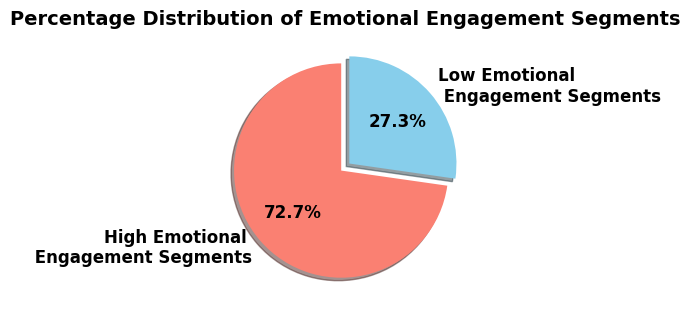

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate percentage of each class
value_counts = df['probe'].value_counts(normalize=True).sort_index() * 100
print(value_counts)

# Custom labels for the classes
labels = ['High Emotional \n Engagement Segments', 'Low Emotional \n Engagement Segments']

# Pie chart plotting
plt.figure(figsize=(6, 6))
plt.pie(
    value_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=['salmon', 'skyblue'],  # match label order (0 -> high, 1 -> low)
    explode=[0.05, 0.05],
    shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

plt.title('Percentage Distribution of Emotional Engagement Segments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


probe
0.0    72.742001
1.0    27.257999
Name: proportion, dtype: float64


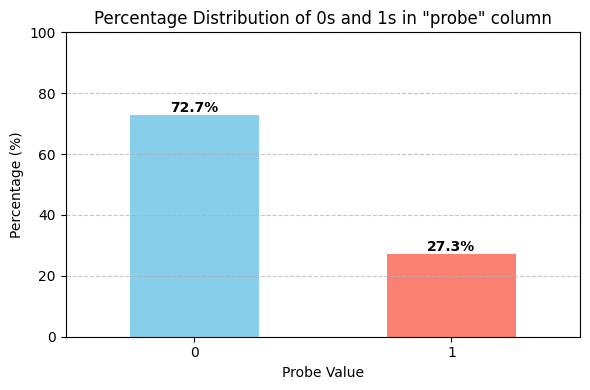

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate percentage of each class
value_counts = df['probe'].value_counts(normalize=True).sort_index() * 100
print(value_counts)

# Plotting
plt.figure(figsize=(6, 4))
value_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Percentage Distribution of 0s and 1s in "probe" column')
plt.xlabel('Probe Value')
plt.ylabel('Percentage (%)')
plt.xticks([0, 1], ['0', '1'], rotation=0)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate the bars with percentage values
for i, value in enumerate(value_counts):
    plt.text(i, value + 1, f'{value:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


probe  0.0  1.0  total  0_percent  1_percent
P_id                                        
1      171   78    249  68.674699  31.325301
2      151   99    250  60.400000  39.600000
3      162   87    249  65.060241  34.939759
4      184   66    250  73.600000  26.400000
5      173   77    250  69.200000  30.800000
6      177   74    251  70.517928  29.482072
7      156   90    246  63.414634  36.585366
8      193   52    245  78.775510  21.224490
9      189   61    250  75.600000  24.400000
10     166   83    249  66.666667  33.333333
11     130  104    234  55.555556  44.444444
12     171   74    245  69.795918  30.204082
13     182   68    250  72.800000  27.200000
14     185   45    230  80.434783  19.565217
15     167   83    250  66.800000  33.200000
16     196   54    250  78.400000  21.600000
17     182   56    238  76.470588  23.529412
18     143  107    250  57.200000  42.800000
19     189   62    251  75.298805  24.701195
20     170   81    251  67.729084  32.270916
21     183

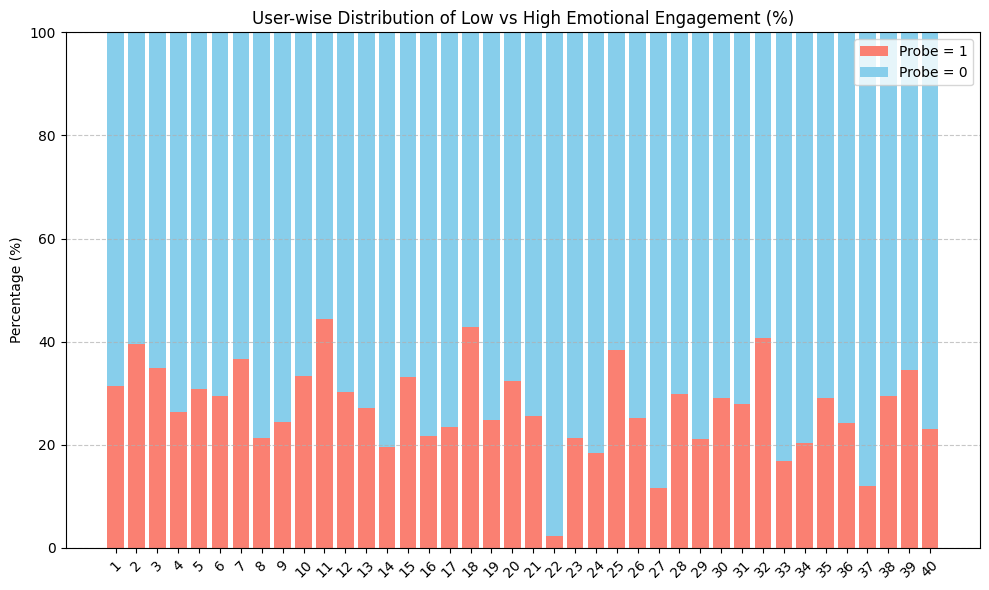

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Example dataframe (replace with your actual df)
# df = pd.DataFrame({
#     'P_id': [1, 1, 1, 2, 2, 2, 2, 3, 3],
#     'probe': [0, 1, 0, 1, 1, 0, 0, 1, 1]
# })

# Count occurrences of probe per P_id
probe_counts = df.groupby(['P_id', 'probe']).size().unstack(fill_value=0)

# Ensure both 0 and 1 columns exist
if 0 not in probe_counts.columns:
    probe_counts[0] = 0
if 1 not in probe_counts.columns:
    probe_counts[1] = 0

# Compute total probes per user
probe_counts['total'] = probe_counts[0] + probe_counts[1]

# Compute percentages
probe_counts['0_percent'] = (probe_counts[0] / probe_counts['total']) * 100
probe_counts['1_percent'] = (probe_counts[1] / probe_counts['total']) * 100

print(probe_counts)

# --- Plot: stacked bar with 1s at bottom and 0s at top ---
plt.figure(figsize=(10, 6))

x = range(len(probe_counts))

# 1s go at the bottom
plt.bar(x, probe_counts['1_percent'], 
        label='Probe = 1', color='salmon')

# 0s stacked on top of 1s
plt.bar(x, probe_counts['0_percent'], 
        bottom=probe_counts['1_percent'], 
        label='Probe = 0', color='skyblue')

# Labels & Formatting
plt.xticks(x, probe_counts.index, rotation=45)
plt.ylabel("Percentage (%)")
plt.title("User-wise Distribution of Low vs High Emotional Engagement (%)")
plt.ylim(0, 100)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()




Class distribution of 'probe':
 probe
0.0    0.72742
1.0    0.27258
Name: proportion, dtype: float64


<Axes: title={'center': 'Class Distribution of probe'}, xlabel='probe'>

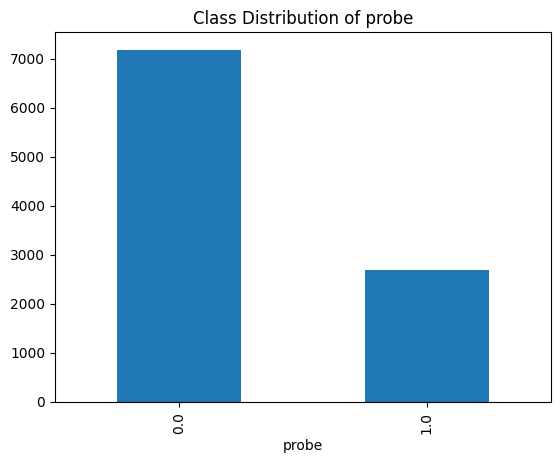

In [16]:
print("Class distribution of 'probe':\n", df['probe'].value_counts(normalize=True))
df['probe'].value_counts().plot(kind='bar', title='Class Distribution of probe')


In [17]:
df.describe().T[['mean', 'std', 'min', 'max']]


,mean,std,min,max
GSR_mean,5.717843e-01,2.259230e-01,1.490683e-02,9.884337e-01
GSR_variance,2.795922e-03,7.960029e-03,1.720471e-06,1.353116e-01
HR_mean,3.723242e-01,1.562311e-01,3.031983e-02,9.989990e-01
HR_variance,5.987203e-03,8.337344e-03,1.602603e-07,1.280730e-01
75_percentile_GSR,5.985003e-01,2.258802e-01,1.863354e-02,9.934211e-01
75_percentile_HR,3.937771e-01,1.633879e-01,3.411514e-02,9.989785e-01
GSRmean_persen_diff,1.783015e-01,1.439510e-01,6.012644e-06,7.741858e-01
HRmean_persent_diff,1.172607e-01,1.120917e-01,4.805048e-06,5.621168e-01
GSRmean_diff,1.783015e-01,1.439510e-01,6.012644e-06,7.741858e-01
HRmean_diff,1.172607e-01,1.120917e-01,4.805048e-06,5.621168e-01


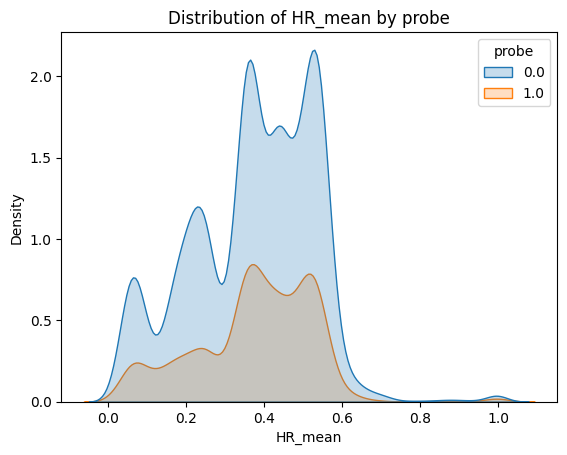

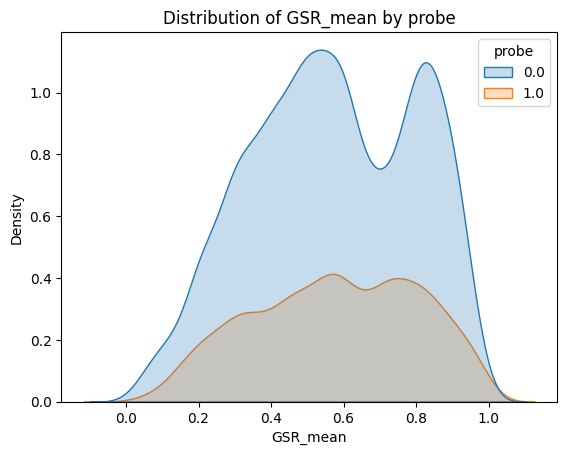

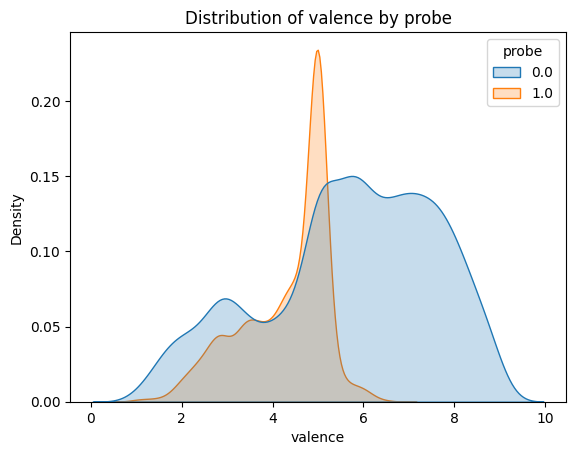

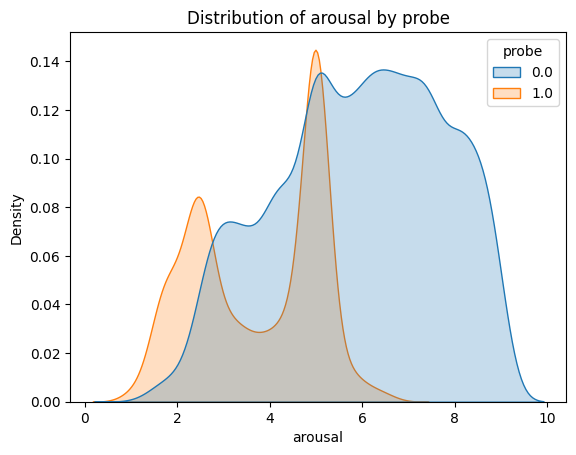

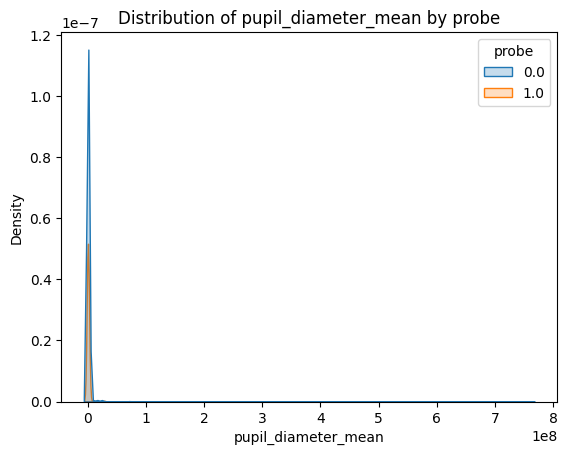

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

features_to_plot = ['HR_mean', 'GSR_mean', 'valence', 'arousal', 'pupil_diameter_mean']  # You can expand this
for feature in features_to_plot:
    sns.kdeplot(data=df, x=feature, hue='probe', fill=True)
    plt.title(f'Distribution of {feature} by probe')
    plt.show()


probe
0.0    7184
1.0    2692
Name: count, dtype: int64


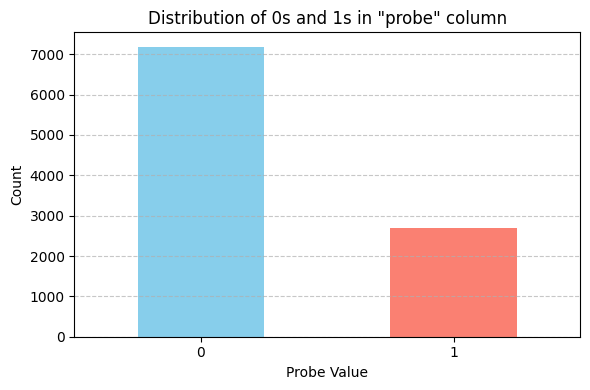

In [8]:
#Number of 0s and 1s
import pandas as pd
import matplotlib.pyplot as plt

# Count occurrences of 0s and 1s
value_counts = df['probe'].value_counts().sort_index()
print(value_counts)
# Plotting
plt.figure(figsize=(6, 4))
value_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of 0s and 1s in "probe" column')
plt.xlabel('Probe Value')
plt.ylabel('Count')
plt.xticks([0, 1], ['0', '1'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [9]:
df.head()

,GSR_mean,GSR_variance,HR_mean,HR_variance,75_percentile_GSR,75_percentile_HR,GSRmean_persen_diff,HRmean_persent_diff,GSRmean_diff,HRmean_diff,...,confidence_y_std,blink_count,gaze_movement_mean,gaze_movement_std,gaze_dir_variability,eye_center_movement_mean,eye_center_movement_std,missing_value_ratio,start_time_ms,end_time_ms
0,0.425789,0.003011,0.259574,0.001005,0.473684,0.265957,0.267649,0.235091,0.267649,0.235091,...,0.096104,50.0,24.882023,83.095608,0.076767,1.060841,5.623409,0.033292,1.752928e+12,1.752928e+12
1,0.425263,0.002531,0.257660,0.001056,0.447368,0.265957,0.268175,0.237006,0.268175,0.237006,...,0.061131,11.5,6.114482,30.423697,0.070928,0.215434,2.928634,0.019662,1.752928e+12,1.752928e+12
2,0.517895,0.003336,0.248511,0.001411,0.552632,0.263298,0.175543,0.246155,0.175543,0.246155,...,0.061131,11.5,6.114482,30.423697,0.070928,0.215434,2.928634,0.019662,1.752928e+12,1.752928e+12
3,0.526316,0.006039,0.265957,0.002856,0.572368,0.297872,0.167122,0.228708,0.167122,0.228708,...,0.061131,11.5,6.114482,30.423697,0.070928,0.215434,2.928634,0.019662,1.752928e+12,1.752928e+12
4,0.457895,0.002521,0.263404,0.001791,0.500000,0.276596,0.235543,0.231261,0.235543,0.231261,...,0.061131,11.5,6.114482,30.423697,0.070928,0.215434,2.928634,0.019662,1.752928e+12,1.752928e+12


In [10]:
df.columns

Index(['GSR_mean', 'GSR_variance', 'HR_mean', 'HR_variance',
       '75_percentile_GSR', '75_percentile_HR', 'GSRmean_persen_diff',
       'HRmean_persent_diff', 'GSRmean_diff', 'HRmean_diff',
       'valence_acc_video', 'arousal_acc_video', 'P_id', 'video_id', 'Score',
       'time', 'valence', 'arousal', 'videoID', 'start_time', 'end_time',
       'probe', 'prev_window', 'start_time_sec', 'end_time_sec', 'num_samples',
       'pupil_diameter_mean', 'pupil_diameter_std', 'diameter_3d_mean',
       'diameter_3d_std', 'sphere_radius_mean', 'circle_3d_radius_mean',
       'ellipse_axis_a_mean', 'ellipse_axis_b_mean', 'ellipse_angle_mean',
       'ellipse_angle_std', 'confidence_x_mean', 'confidence_y_mean',
       'confidence_x_std', 'confidence_y_std', 'blink_count',
       'gaze_movement_mean', 'gaze_movement_std', 'gaze_dir_variability',
       'eye_center_movement_mean', 'eye_center_movement_std',
       'missing_value_ratio', 'start_time_ms', 'end_time_ms'],
      dtype='object')

In [32]:
drop_cols = ['start_time', 'start_time_sec', 'start_time_ms',
             'end_time', 'end_time_sec', 'end_time_ms', 'time', 'videoID']

# Also drop IDs and labels from feature set
# drop_cols += ['P_id', 'video_id', 'videoID']  # if not meant as features
# drop_cols += ['P_id', 'video_id', 'videoID']  # if not meant as features


df = df.drop(columns=drop_cols, errors='ignore')

In [12]:
df.columns

Index(['GSR_mean', 'GSR_variance', 'HR_mean', 'HR_variance',
       '75_percentile_GSR', '75_percentile_HR', 'GSRmean_persen_diff',
       'HRmean_persent_diff', 'GSRmean_diff', 'HRmean_diff',
       'valence_acc_video', 'arousal_acc_video', 'Score', 'valence', 'arousal',
       'probe', 'prev_window', 'num_samples', 'pupil_diameter_mean',
       'pupil_diameter_std', 'diameter_3d_mean', 'diameter_3d_std',
       'sphere_radius_mean', 'circle_3d_radius_mean', 'ellipse_axis_a_mean',
       'ellipse_axis_b_mean', 'ellipse_angle_mean', 'ellipse_angle_std',
       'confidence_x_mean', 'confidence_y_mean', 'confidence_x_std',
       'confidence_y_std', 'blink_count', 'gaze_movement_mean',
       'gaze_movement_std', 'gaze_dir_variability', 'eye_center_movement_mean',
       'eye_center_movement_std', 'missing_value_ratio'],
      dtype='object')

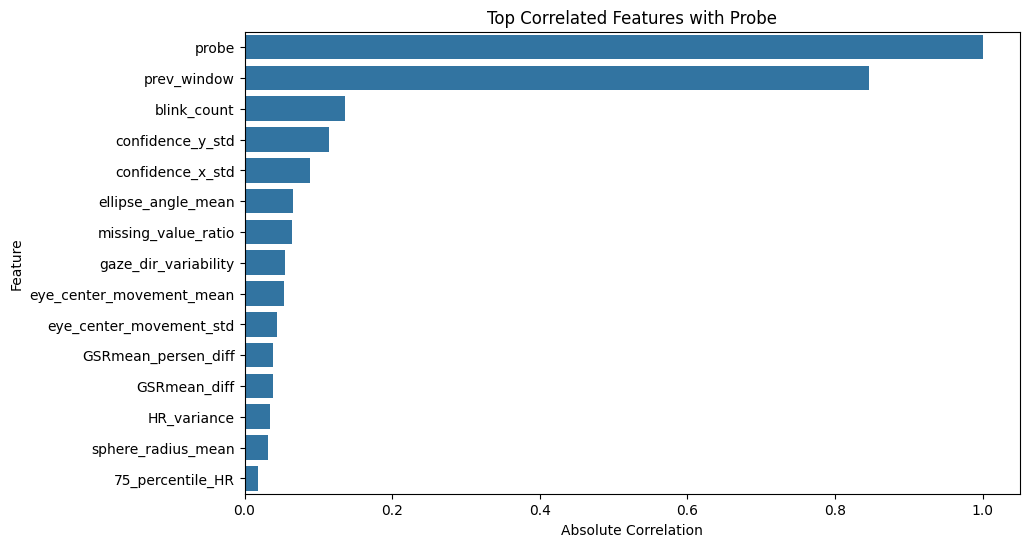

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt


# Compute correlations
corr = df.corr(numeric_only=True)

# Correlation with the label
label_corr = corr['probe'].sort_values(ascending=False)

# Plot top correlated features with 'probe'
plt.figure(figsize=(10, 6))
sns.barplot(x=label_corr.abs().head(15), y=label_corr.abs().head(15).index)
plt.title('Top Correlated Features with Probe')
plt.xlabel('Absolute Correlation')
plt.ylabel('Feature')
plt.show()


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Prepare data
X = df.drop(columns=['probe'])
y = df['probe']

# Optional: drop non-numeric or non-useful columns
X = X.select_dtypes(include=['number'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


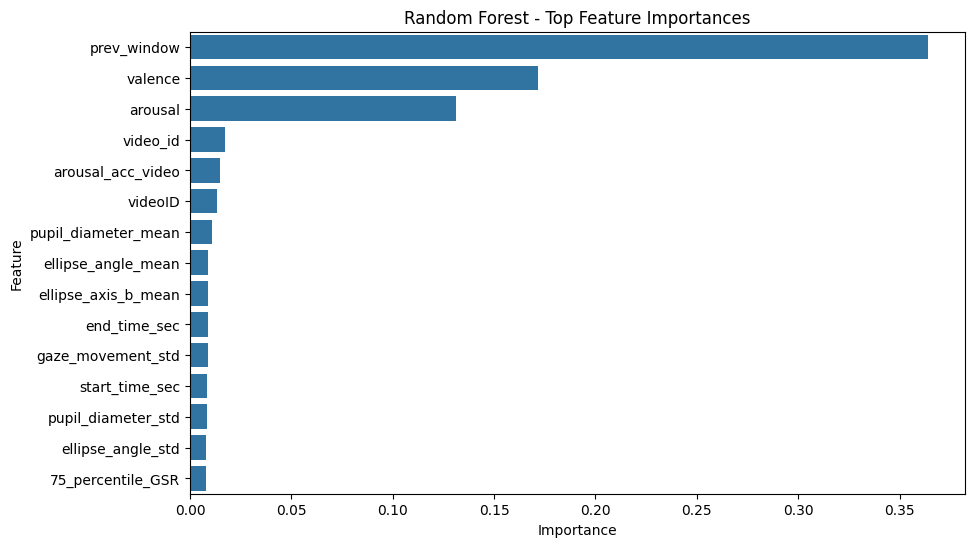

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# drop_cols = ['start_time', 'start_time_sec', 'start_time_ms',
#              'end_time', 'end_time_sec', 'end_time_ms', 'time']

# # Also drop IDs and labels from feature set
# drop_cols += ['P_id', 'video_id', 'videoID', 'probe']  # if not meant as features

# # Features only
# X = df.drop(columns=drop_cols, errors='ignore')
# y = df['probe']



# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.head(15), y=importances.head(15).index)
plt.title("Random Forest - Top Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [21]:
missing = X.isnull().sum()
print("Missing values per feature:\n", missing[missing > 0])


Missing values per feature:
 Score    321
dtype: int64


In [22]:
X = X.dropna()
y = y.loc[X.index]  # Make sure y matches X


In [23]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
rfe = RFE(model, n_features_to_select=10)
fit = rfe.fit(X, y)

# Selected features
selected_features = X.columns[fit.support_]
print("Top 10 features selected by RFE:", selected_features.tolist())


Top 10 features selected by RFE: ['time', 'start_time_sec', 'end_time_sec', 'pupil_diameter_mean', 'pupil_diameter_std', 'ellipse_axis_b_mean', 'gaze_movement_mean', 'gaze_movement_std', 'start_time_ms', 'end_time_ms']


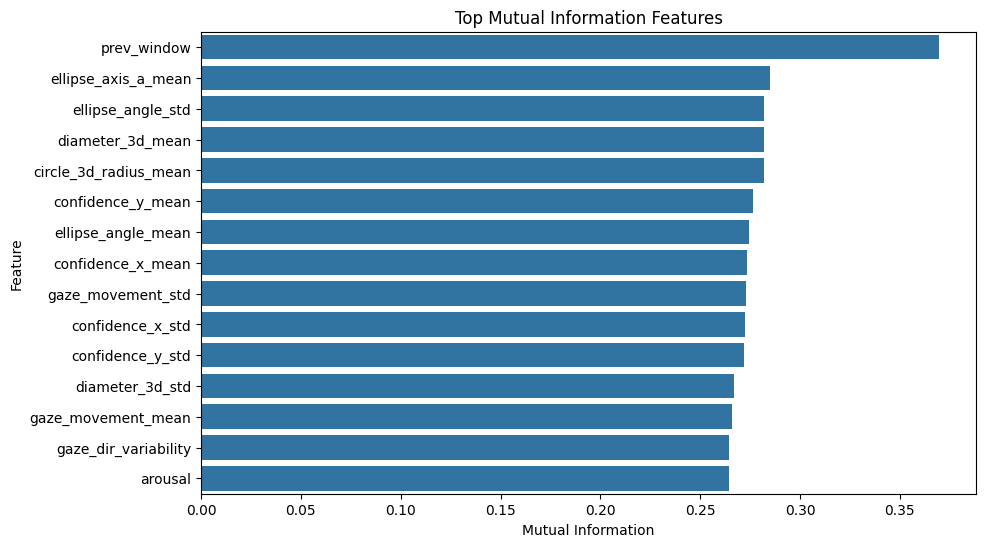

In [19]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y, discrete_features='auto')
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=mi_series.head(15), y=mi_series.head(15).index)
plt.title("Top Mutual Information Features")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.show()


In [24]:
from sklearn.feature_selection import VarianceThreshold

# Low variance filter
selector = VarianceThreshold(threshold=0.01)
selector.fit(X)
low_variance_features = X.columns[~selector.get_support()]

# High missing values
missing_ratios = df.isnull().mean()
high_missing = missing_ratios[missing_ratios > 0.3]

print("Low variance features:", low_variance_features.tolist())
print("High missing value features:", high_missing.index.tolist())


Low variance features: ['GSR_variance', 'HR_variance', 'sphere_radius_mean', 'confidence_x_mean', 'confidence_y_mean', 'confidence_x_std', 'confidence_y_std', 'gaze_dir_variability', 'missing_value_ratio']
High missing value features: []


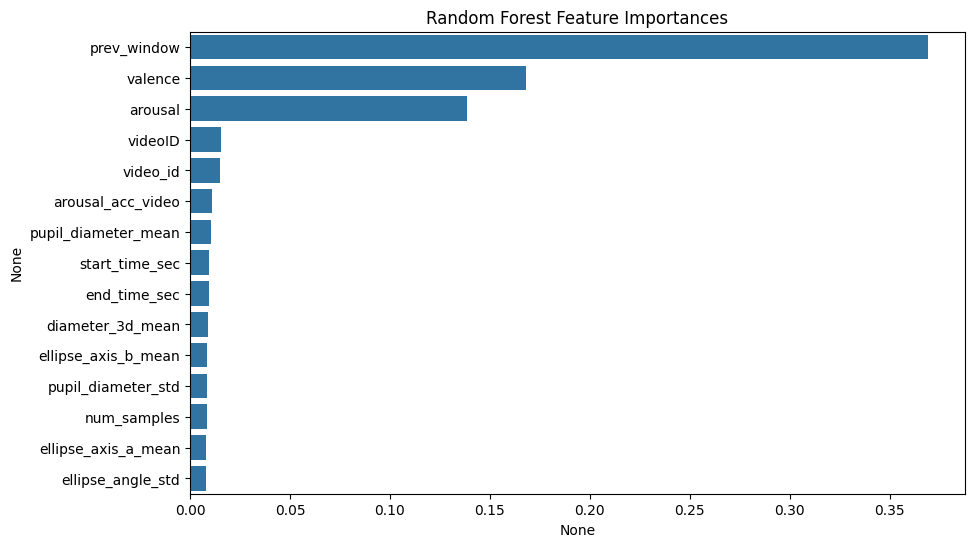

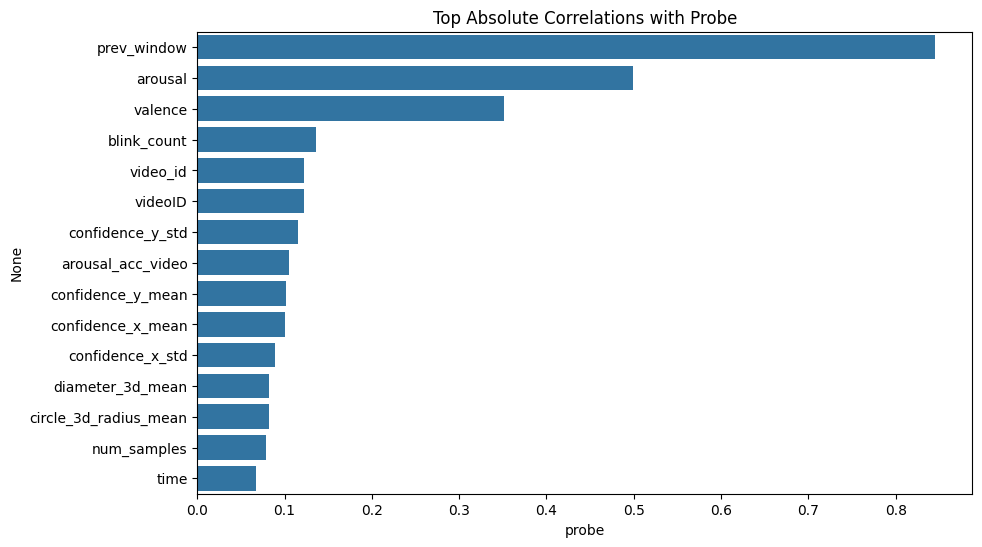

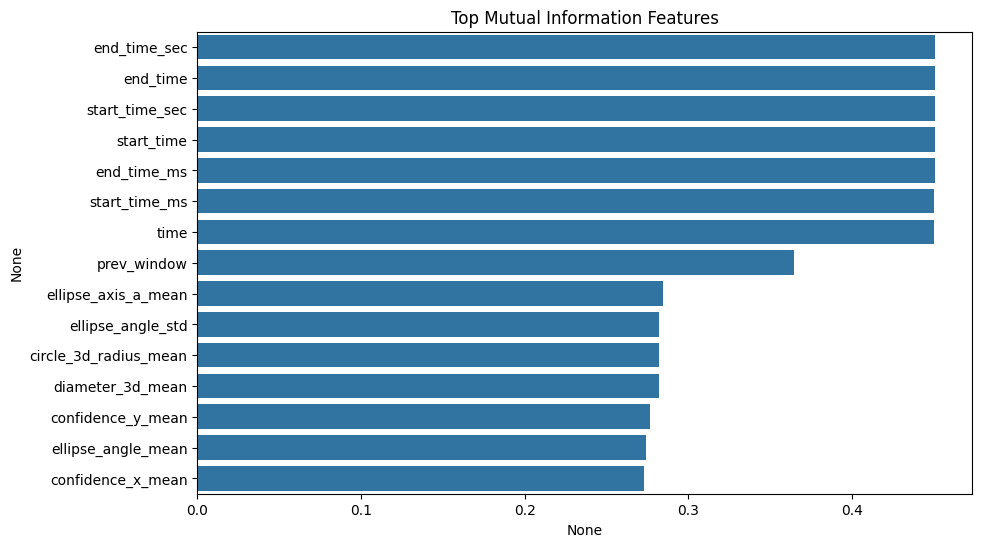

✅ Top 20 features selected by RFE: ['P_id', 'time', 'valence', 'arousal', 'start_time', 'end_time', 'prev_window', 'start_time_sec', 'end_time_sec', 'num_samples', 'pupil_diameter_mean', 'pupil_diameter_std', 'ellipse_axis_b_mean', 'ellipse_angle_mean', 'blink_count', 'gaze_movement_mean', 'gaze_movement_std', 'eye_center_movement_std', 'start_time_ms', 'end_time_ms']


In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X.select_dtypes(include='number'), y, test_size=0.2, random_state=42)

# ---- Random Forest Feature Importance ----
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=rf_importances.head(15), y=rf_importances.head(15).index)
plt.title("Random Forest Feature Importances")
plt.show()

# ---- Correlation with Probe ----
corr = df[X.columns.tolist() + ['probe']].corr(numeric_only=True)
probe_corr = corr['probe'].drop('probe').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=probe_corr.head(15).abs(), y=probe_corr.head(15).index)
plt.title("Top Absolute Correlations with Probe")
plt.show()

# ---- Mutual Information ----
mi = mutual_info_classif(X, y)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=mi_series.head(15), y=mi_series.head(15).index)
plt.title("Top Mutual Information Features")
plt.show()

# ---- RFE (Recursive Feature Elimination) ----
rfe_model = LogisticRegression(max_iter=1000)
rfe = RFE(rfe_model, n_features_to_select=20)
rfe.fit(X, y)

selected_rfe = X.columns[rfe.support_]
print("✅ Top 20 features selected by RFE:", selected_rfe.tolist())


In [22]:
df.shape

(9876, 39)

In [23]:
df.columns

Index(['GSR_mean', 'GSR_variance', 'HR_mean', 'HR_variance',
       '75_percentile_GSR', '75_percentile_HR', 'GSRmean_persen_diff',
       'HRmean_persent_diff', 'GSRmean_diff', 'HRmean_diff',
       'valence_acc_video', 'arousal_acc_video', 'Score', 'valence', 'arousal',
       'probe', 'prev_window', 'num_samples', 'pupil_diameter_mean',
       'pupil_diameter_std', 'diameter_3d_mean', 'diameter_3d_std',
       'sphere_radius_mean', 'circle_3d_radius_mean', 'ellipse_axis_a_mean',
       'ellipse_axis_b_mean', 'ellipse_angle_mean', 'ellipse_angle_std',
       'confidence_x_mean', 'confidence_y_mean', 'confidence_x_std',
       'confidence_y_std', 'blink_count', 'gaze_movement_mean',
       'gaze_movement_std', 'gaze_dir_variability', 'eye_center_movement_mean',
       'eye_center_movement_std', 'missing_value_ratio'],
      dtype='object')

# Feature Analysis Report

In [24]:
# Feature Analysis Report


🔍 Correlation of each feature with the target variable 'probe':
blink_count                 0.136234
confidence_y_std            0.115100
arousal_acc_video          -0.105071
confidence_y_mean          -0.101103
confidence_x_mean          -0.100271
confidence_x_std            0.088484
diameter_3d_mean           -0.081849
circle_3d_radius_mean      -0.081849
num_samples                -0.078488
ellipse_angle_mean          0.066336
missing_value_ratio         0.063922
valence_acc_video          -0.061397
ellipse_axis_a_mean        -0.058271
gaze_dir_variability        0.054559
eye_center_movement_mean    0.052869
eye_center_movement_std     0.043412
GSRmean_diff                0.038191
GSRmean_persen_diff         0.038191
HR_variance                 0.033914
gaze_movement_mean         -0.032773
sphere_radius_mean          0.031686
gaze_movement_std          -0.024593
75_percentile_HR            0.018429
GSR_mean                    0.016085
75_percentile_GSR           0.015163
HR_mean   

/tmp/ipykernel_1956374/2374593714.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_probe_corr.values, y=top_probe_corr.index, palette='coolwarm')


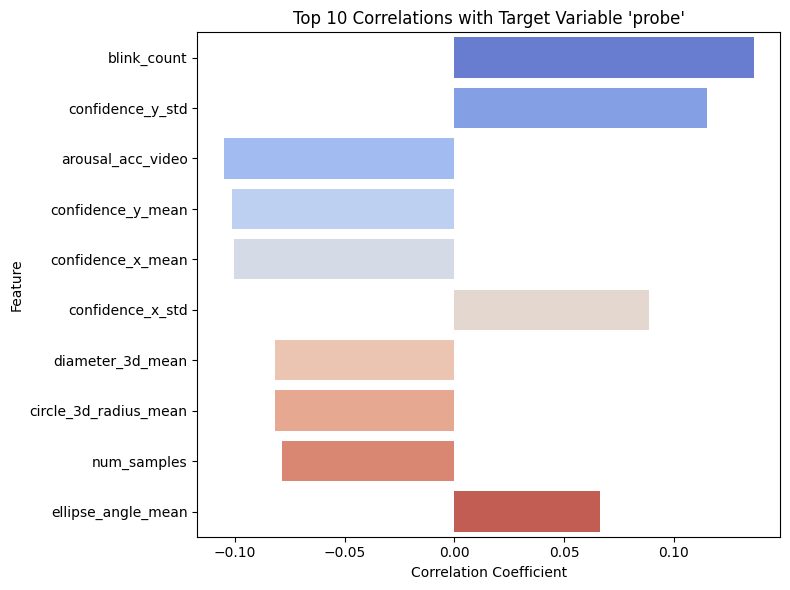

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Drop irrelevant columns
drop_cols = [
    'start_time', 'start_time_sec', 'start_time_ms',
    'end_time', 'end_time_sec', 'end_time_ms', 'time',
    'P_id', 'video_id', 'videoID', 'arousal', 'valence', 'prev_window'
]
df_clean = df.drop(columns=[col for col in drop_cols if col in df.columns])

# Step 2: Compute Pearson correlation matrix
corr_matrix = df_clean.corr(method='pearson')

# Step 3: Focus on correlations with 'probe'
if 'probe' in corr_matrix.columns:
    print("\n🔍 Correlation of each feature with the target variable 'probe':")
    probe_corr = corr_matrix['probe'].drop('probe').sort_values(key=abs, ascending=False)
    print(probe_corr.to_string())

    # Optional: visualize top 10 correlated features with probe
    top_n = 10
    top_probe_corr = probe_corr.head(top_n)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=top_probe_corr.values, y=top_probe_corr.index, palette='coolwarm')
    plt.title(f"Top {top_n} Correlations with Target Variable 'probe'")
    plt.xlabel("Correlation Coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("The column 'probe' was not found in the DataFrame.")



🔍 Top 10 correlations with 'probe':
75_percentile_GSR      -0.181183
GSR_mean               -0.163838
HRmean_persent_diff     0.114243
HRmean_diff             0.114243
GSR_variance           -0.075249
confidence_y_mean       0.065059
confidence_x_mean       0.064433
gaze_dir_variability    0.060634
ellipse_angle_std       0.057356
GSRmean_persen_diff     0.055345
Name: Score, dtype: float64


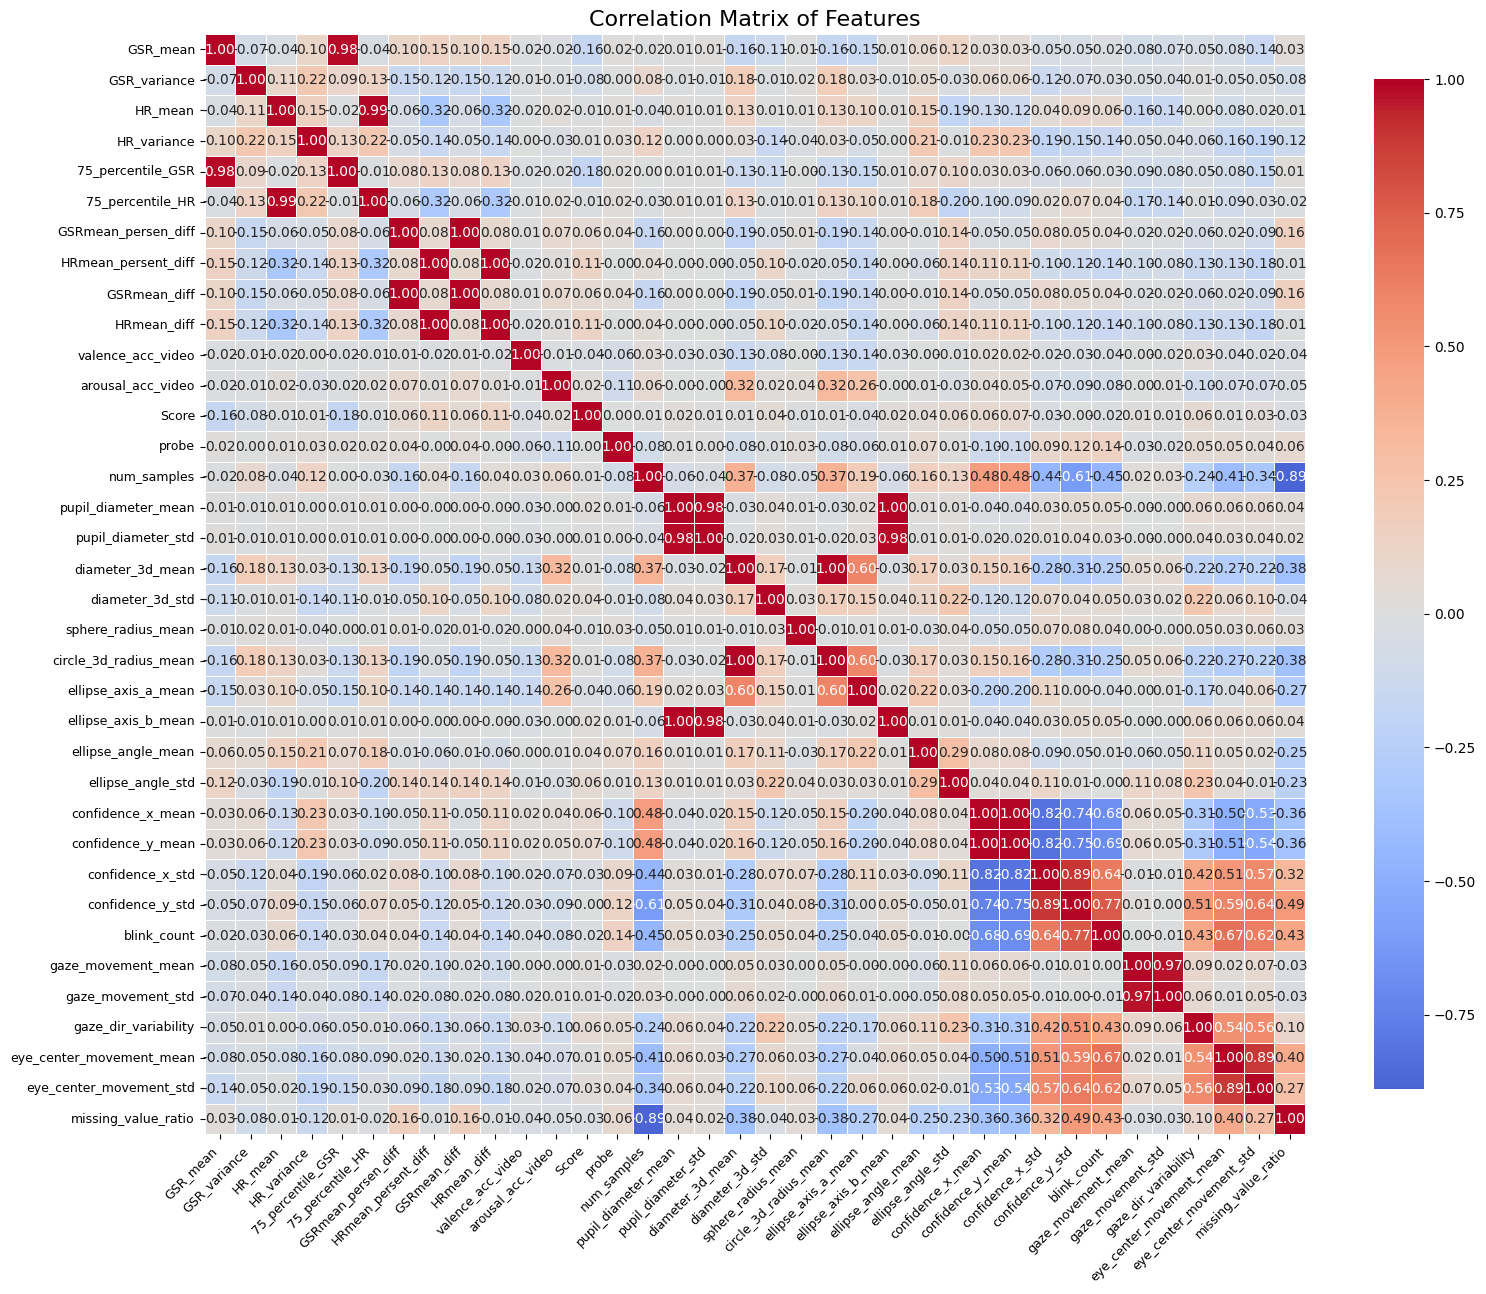

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Drop unwanted columns
drop_cols = [
    'start_time', 'start_time_sec', 'start_time_ms',
    'end_time', 'end_time_sec', 'end_time_ms', 'time',
    'P_id', 'video_id', 'videoID', 'arousal', 'valence', 'prev_window'
]

# Drop columns that are present
df_clean = df.drop(columns=[col for col in drop_cols if col in df.columns])

# Step 2: Compute Pearson correlation matrix
corr_matrix = df_clean.corr(method='pearson')

# Step 3: Print top correlations with 'Score' (if it exists)
if 'probe' in corr_matrix.columns:
    print("\n🔍 Top 10 correlations with 'probe':")
    score_corr = corr_matrix['Score'].drop('Score').sort_values(key=abs, ascending=False)
    print(score_corr.head(10))

# # Step 4: Print highly correlated feature pairs (absolute value > 0.85)
# print("\n📌 Highly correlated feature pairs (|correlation| > 0.85):")
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
# high_corr = corr_matrix.where(mask).stack().reset_index()
# high_corr.columns = ['Feature 1', 'Feature 2', 'Correlation']
# strong_corr_pairs = high_corr[abs(high_corr['Correlation']) > 0.85]
# print(strong_corr_pairs)

# Step 5: Plot heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title("Correlation Matrix of Features", fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()


In [27]:
# Correlation of each feature with the label 'probe'
target_corr = corr_matrix['probe'].drop('probe').sort_values(key=abs, ascending=False)

# Display top N most correlated features with the label
top_n = 20
print("Top features correlated with 'probe':")
print(target_corr.head(top_n))


Top features correlated with 'probe':
blink_count                 0.136234
confidence_y_std            0.115100
arousal_acc_video          -0.105071
confidence_y_mean          -0.101103
confidence_x_mean          -0.100271
confidence_x_std            0.088484
diameter_3d_mean           -0.081849
circle_3d_radius_mean      -0.081849
num_samples                -0.078488
ellipse_angle_mean          0.066336
missing_value_ratio         0.063922
valence_acc_video          -0.061397
ellipse_axis_a_mean        -0.058271
gaze_dir_variability        0.054559
eye_center_movement_mean    0.052869
eye_center_movement_std     0.043412
GSRmean_diff                0.038191
GSRmean_persen_diff         0.038191
HR_variance                 0.033914
gaze_movement_mean         -0.032773
Name: probe, dtype: float64


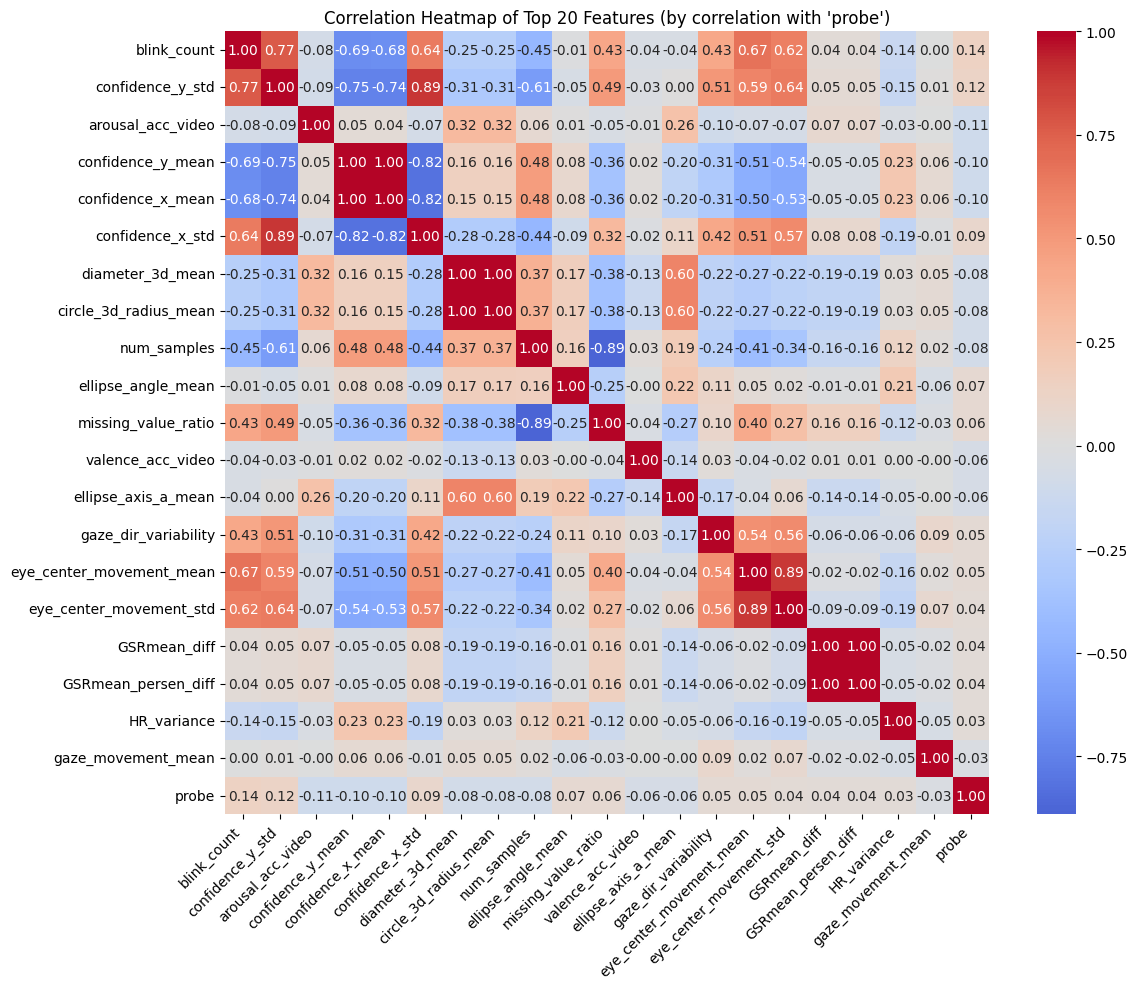

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Keep only top-N correlated features with 'probe'
top_n = 20

# Assuming 'corr_matrix' and 'df_clean' already exist
# If not, recompute as in earlier step
target_corr = df_clean.corr()['probe'].drop('probe')
top_features = target_corr.abs().sort_values(ascending=False).head(top_n).index.tolist()

# Include 'probe' for correlation context
top_features_with_label = top_features + ['probe']

# Step 2: Subset the correlation matrix
filtered_corr = df_clean[top_features_with_label].corr()

# Step 3: Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(filtered_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title(f"Correlation Heatmap of Top {top_n} Features (by correlation with 'probe')")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


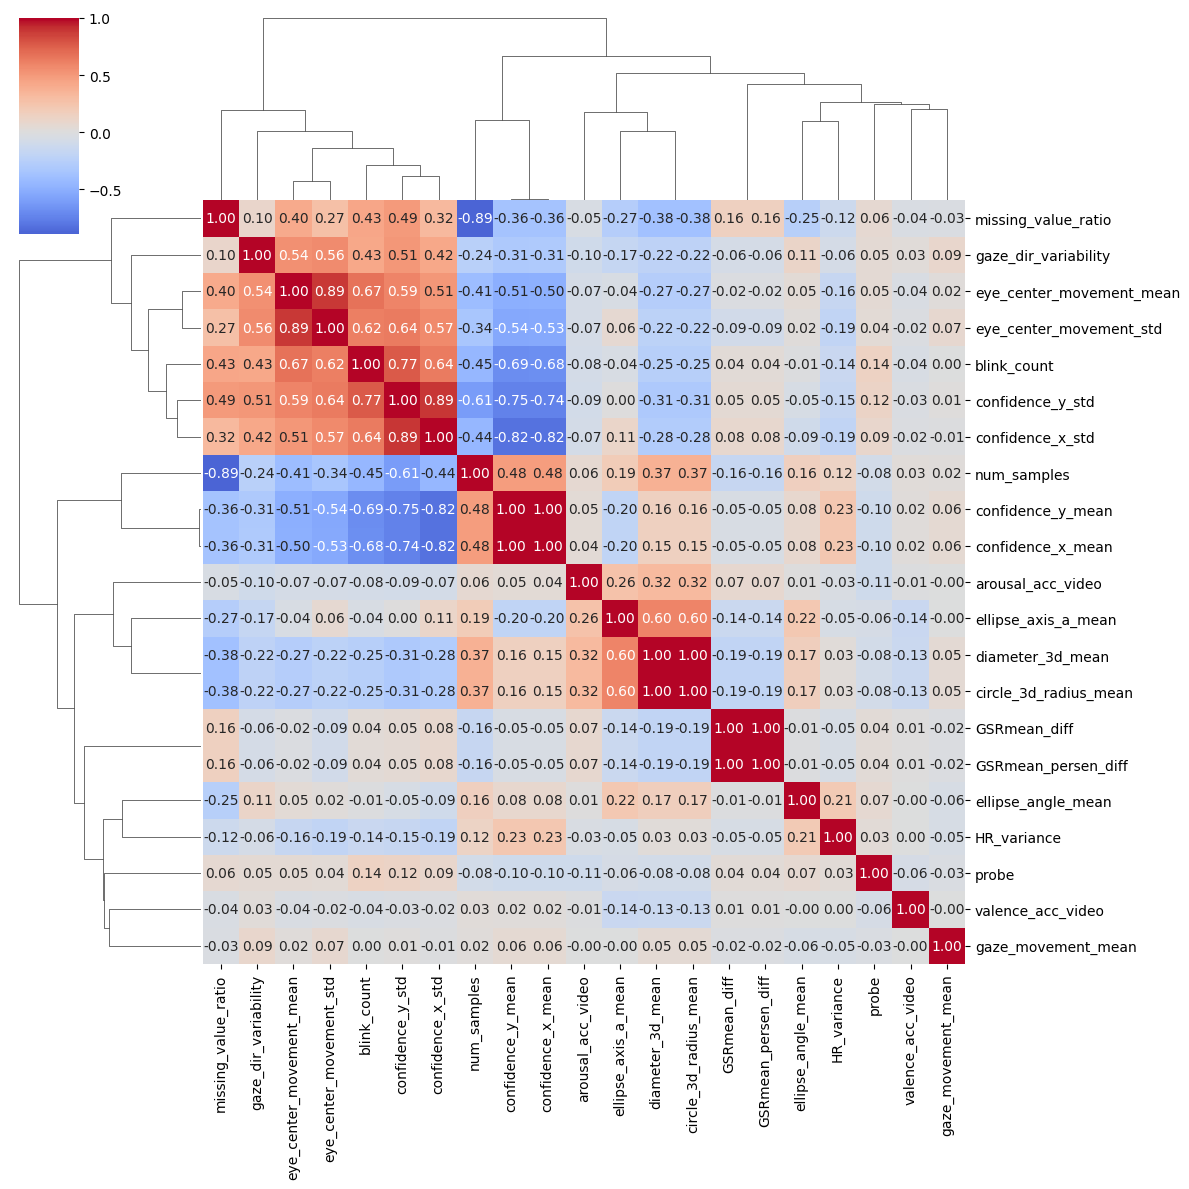

In [29]:
sns.clustermap(filtered_corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', figsize=(12, 12))


/tmp/ipykernel_1748656/962048373.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df.head(top_n), x='Importance', y='Feature', palette='viridis')


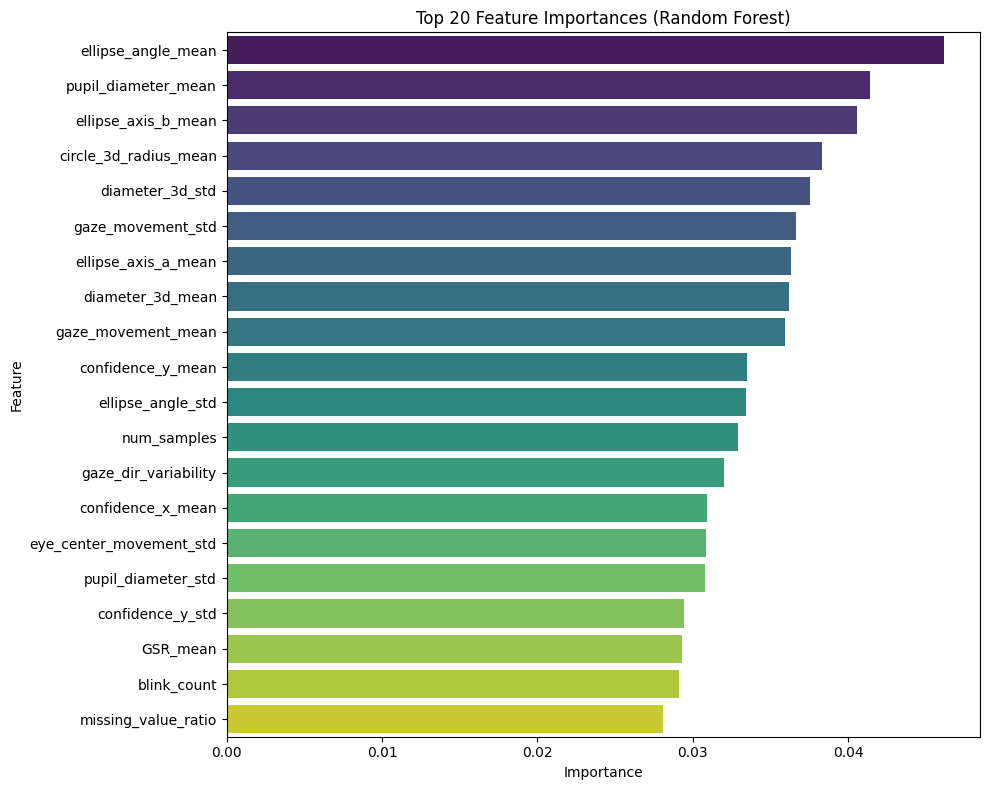

                    Feature  Importance
22       ellipse_angle_mean    0.046176
14      pupil_diameter_mean    0.041398
21      ellipse_axis_b_mean    0.040551
19    circle_3d_radius_mean    0.038318
17          diameter_3d_std    0.037539
30        gaze_movement_std    0.036642
20      ellipse_axis_a_mean    0.036326
16         diameter_3d_mean    0.036166
29       gaze_movement_mean    0.035941
25        confidence_y_mean    0.033494
23        ellipse_angle_std    0.033449
13              num_samples    0.032938
31     gaze_dir_variability    0.032040
24        confidence_x_mean    0.030935
33  eye_center_movement_std    0.030860
15       pupil_diameter_std    0.030808
27         confidence_y_std    0.029403
0                  GSR_mean    0.029278
28              blink_count    0.029097
34      missing_value_ratio    0.028100
X_train shape: (7407, 35)
X_test shape: (2469, 35)
y_train distribution:
probe
0.0    0.72742
1.0    0.27258
Name: proportion, dtype: float64
Random Forest accu

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Prepare data
X = df_clean.drop(columns='probe')
y = df_clean['probe']

# Optional: handle missing values
X = X.fillna(X.median())

# Step 2: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Step 3: Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Step 4: Get feature importances
importances = rf.feature_importances_
features = X.columns

# Put into DataFrame and sort
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)



# Step 5: Plot top N features
top_n = 20
plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp_df.head(top_n), x='Importance', y='Feature', palette='viridis')
plt.title(f'Top {top_n} Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()


print(feat_imp_df.head(top_n))
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts(normalize=True)}")

from sklearn.metrics import accuracy_score

y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest accuracy: {accuracy:.2f}")




[LightGBM] [Info] Number of positive: 2019, number of negative: 5388
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000573 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8068
[LightGBM] [Info] Number of data points in the train set: 7407, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.272580 -> initscore=-0.981572
[LightGBM] [Info] Start training from score -0.981572


/tmp/ipykernel_1748656/130138735.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(top_n), x='Importance', y='Feature', palette='magma')


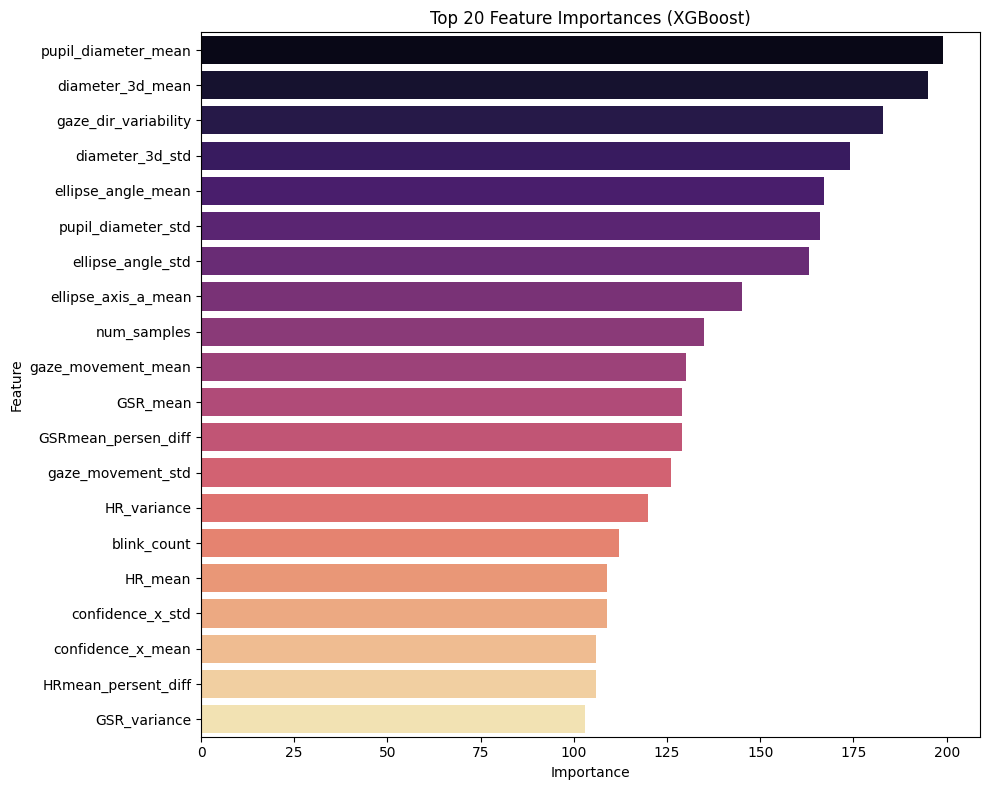

/tmp/ipykernel_1748656/130138735.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(top_n), x='Importance', y='Feature', palette='magma')


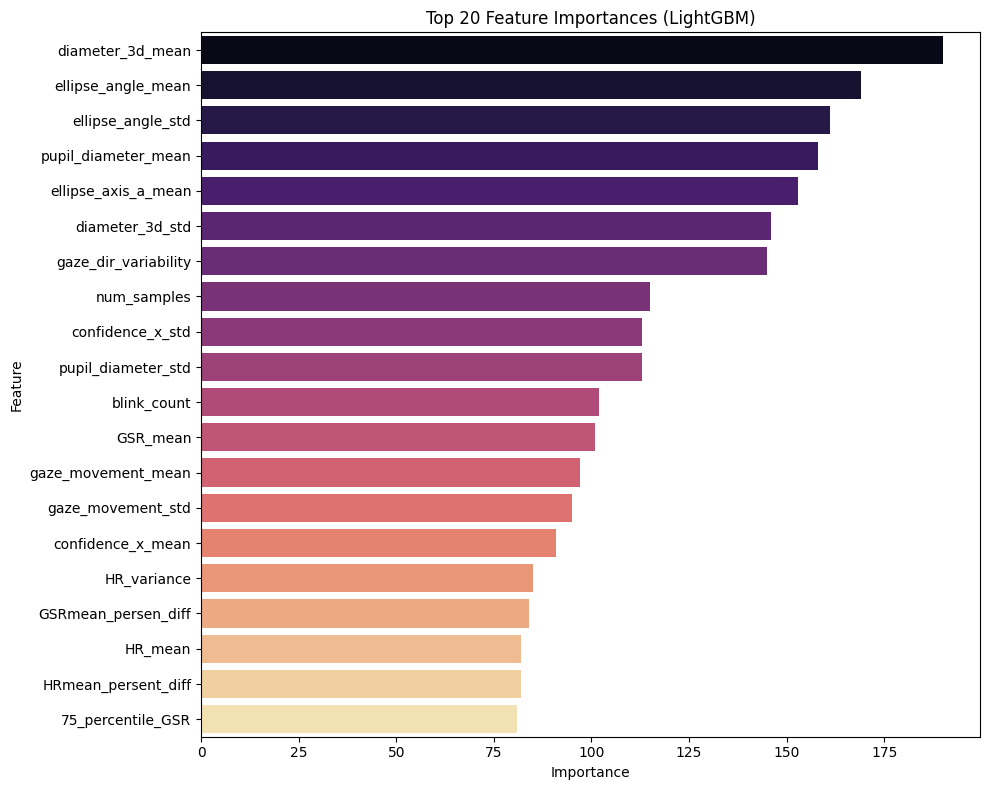


Top 10 features from XGBoost:
                 Feature  Importance
14   pupil_diameter_mean       199.0
16      diameter_3d_mean       195.0
31  gaze_dir_variability       183.0
17       diameter_3d_std       174.0
22    ellipse_angle_mean       167.0
15    pupil_diameter_std       166.0
23     ellipse_angle_std       163.0
20   ellipse_axis_a_mean       145.0
13           num_samples       135.0
29    gaze_movement_mean       130.0

Top 10 features from LightGBM:
                 Feature  Importance
16      diameter_3d_mean         190
22    ellipse_angle_mean         169
23     ellipse_angle_std         161
14   pupil_diameter_mean         158
20   ellipse_axis_a_mean         153
17       diameter_3d_std         146
31  gaze_dir_variability         145
13           num_samples         115
26      confidence_x_std         113
15    pupil_diameter_std         113

XGBoost Accuracy: 0.91
LightGBM Accuracy: 0.89


In [31]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Store results for comparison
importance_results = {}

# 1. XGBoost
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

# xgb_importances = xgb.feature_importances_
# xgb_df = pd.DataFrame({'Feature': X.columns, 'Importance': xgb_importances})
# xgb_df = xgb_df.sort_values(by='Importance', ascending=False)
# importance_results['XGBoost'] = xgb_df

# Get importance from XGBoost booster
xgb_booster = xgb.get_booster()
raw_importances = xgb_booster.get_score(importance_type='weight')

# Create complete importance dict (fill missing with 0)
all_features = X.columns.tolist()
full_importance = {feat: raw_importances.get(feat, 0.0) for feat in all_features}

# Convert to DataFrame
xgb_df = pd.DataFrame({'Feature': list(full_importance.keys()), 
                       'Importance': list(full_importance.values())})
xgb_df = xgb_df.sort_values(by='Importance', ascending=False)




# 2. LightGBM
lgbm = LGBMClassifier(n_estimators=100, random_state=42)
lgbm.fit(X_train, y_train)

lgbm_importances = lgbm.feature_importances_
lgbm_df = pd.DataFrame({'Feature': X.columns, 'Importance': lgbm_importances})
lgbm_df = lgbm_df.sort_values(by='Importance', ascending=False)
importance_results['LightGBM'] = lgbm_df

# 3. Optional: combine and compare top features side-by-side
def plot_feature_importance(df, model_name, top_n=20):
    plt.figure(figsize=(10, 8))
    sns.barplot(data=df.head(top_n), x='Importance', y='Feature', palette='magma')
    plt.title(f'Top {top_n} Feature Importances ({model_name})')
    plt.tight_layout()
    plt.show()

# Plot XGBoost
plot_feature_importance(xgb_df, 'XGBoost')

# Plot LightGBM
plot_feature_importance(lgbm_df, 'LightGBM')

# Print top 10 features from both models
print("\nTop 10 features from XGBoost:")
print(xgb_df.head(10))

print("\nTop 10 features from LightGBM:")
print(lgbm_df.head(10))

# Optional: Evaluate and print accuracy for both models
from sklearn.metrics import accuracy_score

xgb_preds = xgb.predict(X_test)
lgbm_preds = lgbm.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_preds)
lgbm_acc = accuracy_score(y_test, lgbm_preds)

print(f"\nXGBoost Accuracy: {xgb_acc:.2f}")
print(f"LightGBM Accuracy: {lgbm_acc:.2f}")



Train set size: (7165, 40) (7165,)
Test set size: (2711, 40) (2711,)
[LightGBM] [Info] Number of positive: 2208, number of negative: 4957
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000770 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8593
[LightGBM] [Info] Number of data points in the train set: 7165, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.308165 -> initscore=-0.808714
[LightGBM] [Info] Start training from score -0.808714
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

/tmp/ipykernel_1956374/70363014.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(top_n), x='Importance', y='Feature', palette='magma')


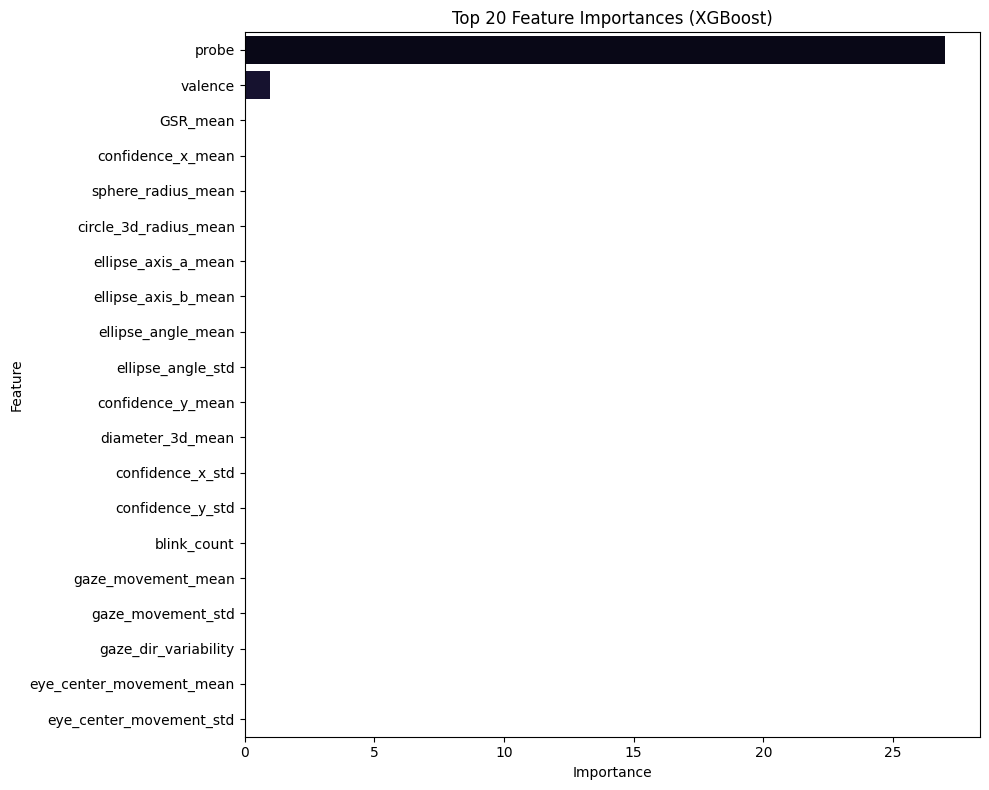

/tmp/ipykernel_1956374/70363014.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(top_n), x='Importance', y='Feature', palette='magma')


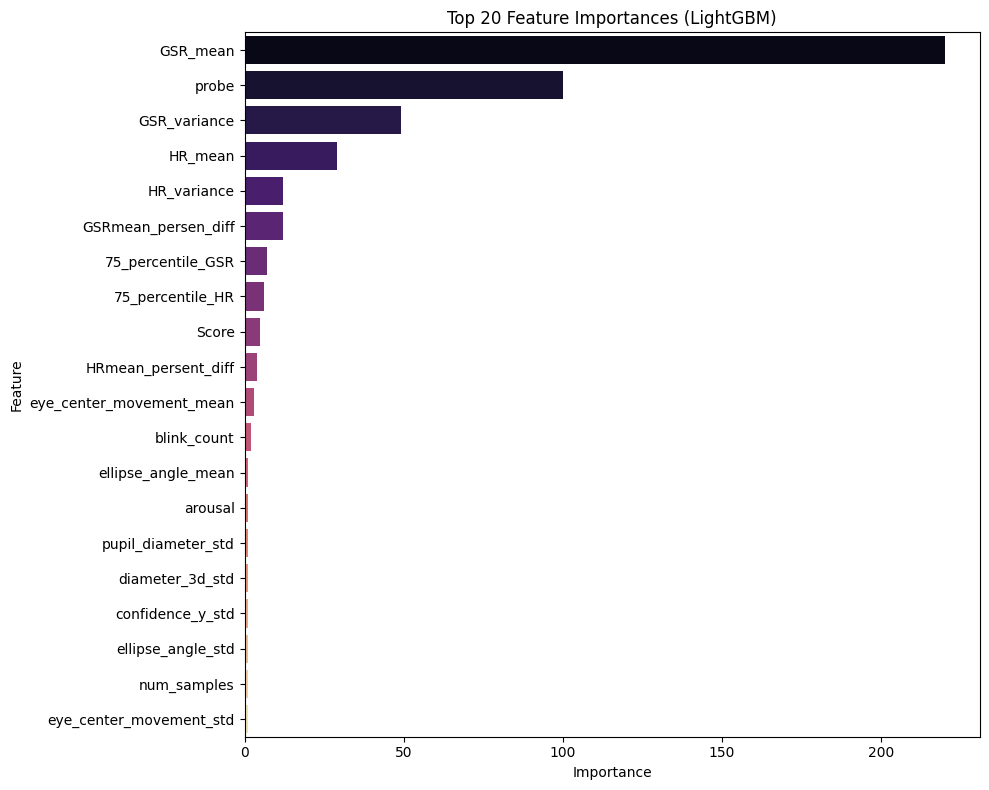


Top 10 features from XGBoost:
                  Feature  Importance
16                  probe        27.0
14                valence         1.0
0                GSR_mean         0.0
29      confidence_x_mean         0.0
23     sphere_radius_mean         0.0
24  circle_3d_radius_mean         0.0
25    ellipse_axis_a_mean         0.0
26    ellipse_axis_b_mean         0.0
27     ellipse_angle_mean         0.0
28      ellipse_angle_std         0.0

Top 10 features from LightGBM:
                Feature  Importance
0              GSR_mean         220
16                probe         100
1          GSR_variance          49
2               HR_mean          29
3           HR_variance          12
6   GSRmean_persen_diff          12
4     75_percentile_GSR           7
5      75_percentile_HR           6
13                Score           5
7   HRmean_persent_diff           4

XGBoost Accuracy: 1.00
LightGBM Accuracy: 1.00

XGBoost Metrics:
  TPR (Recall): 1.000
  FPR: 0.000
  F1-Macro: 1.000

Lig

In [36]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import recall_score, f1_score, confusion_matrix

# Store results for comparison
importance_results = {}
#-------------------------------------------------------------------

# Train/Test split by video_id groups
train_ids = [1, 2, 3, 4, 5, 6]
test_ids  = [7, 8]

# Training set
X_train = df[df["video_id"].isin(train_ids)].drop(columns=["video_id"])
y_train = df[df["video_id"].isin(train_ids)]["probe"]

# Testing set
X_test = df[df["video_id"].isin(test_ids)].drop(columns=["video_id"])
y_test = df[df["video_id"].isin(test_ids)]["probe"]

print("Train set size:", X_train.shape, y_train.shape)
print("Test set size:", X_test.shape, y_test.shape)
#-------------------------------------------------------------------

# 1. XGBoost
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

# Get importance from XGBoost booster
xgb_booster = xgb.get_booster()
raw_importances = xgb_booster.get_score(importance_type='weight')

# Create complete importance dict (fill missing with 0)
all_features = X_train.columns.tolist()
full_importance = {feat: raw_importances.get(feat, 0.0) for feat in all_features}

# Convert to DataFrame
xgb_df = pd.DataFrame({'Feature': list(full_importance.keys()), 
                       'Importance': list(full_importance.values())})
xgb_df = xgb_df.sort_values(by='Importance', ascending=False)


# 2. LightGBM
lgbm = LGBMClassifier(n_estimators=100, random_state=42)
lgbm.fit(X_train, y_train)

lgbm_importances = lgbm.feature_importances_
# lgbm_df = pd.DataFrame({'Feature': X.columns, 'Importance': lgbm_importances})
lgbm_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm_importances
}).sort_values(by='Importance', ascending=False)
lgbm_df = lgbm_df.sort_values(by='Importance', ascending=False)
importance_results['LightGBM'] = lgbm_df


# --- Plotting function ---
def plot_feature_importance(df, model_name, top_n=20):
    plt.figure(figsize=(10, 8))
    sns.barplot(data=df.head(top_n), x='Importance', y='Feature', palette='magma')
    plt.title(f'Top {top_n} Feature Importances ({model_name})')
    plt.tight_layout()
    plt.show()


# Plot XGBoost
plot_feature_importance(xgb_df, 'XGBoost')

# Plot LightGBM
plot_feature_importance(lgbm_df, 'LightGBM')

# Print top 10 features
print("\nTop 10 features from XGBoost:")
print(xgb_df.head(10))

print("\nTop 10 features from LightGBM:")
print(lgbm_df.head(10))


# --- Model Evaluation ---
from sklearn.metrics import accuracy_score

# Predictions
xgb_preds = xgb.predict(X_test)
lgbm_preds = lgbm.predict(X_test)

# Accuracy
xgb_acc = accuracy_score(y_test, xgb_preds)
lgbm_acc = accuracy_score(y_test, lgbm_preds)

print(f"\nXGBoost Accuracy: {xgb_acc:.2f}")
print(f"LightGBM Accuracy: {lgbm_acc:.2f}")

# ---- NEW METRICS: TPR, FPR, F1 ----
def compute_metrics(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    tpr = tp / (tp + fn)  # Recall
    fpr = fp / (fp + tn)
    f1 = f1_score(y_true, y_pred, average="macro")

    print(f"\n{model_name} Metrics:")
    print(f"  TPR (Recall): {tpr:.3f}")
    print(f"  FPR: {fpr:.3f}")
    print(f"  F1-Macro: {f1:.3f}")

# Apply to both models
compute_metrics(y_test, xgb_preds, "XGBoost")
compute_metrics(y_test, lgbm_preds, "LightGBM")


In [32]:
X.describe(include='all').T


,count,mean,std,min,25%,50%,75%,max
GSR_mean,9876.0,5.717843e-01,2.259230e-01,1.490683e-02,0.399472,0.572099,0.771889,9.884337e-01
GSR_variance,9876.0,2.795922e-03,7.960029e-03,1.720471e-06,0.000089,0.000347,0.001034,1.353116e-01
HR_mean,9876.0,3.723242e-01,1.562311e-01,3.031983e-02,0.254681,0.382146,0.498636,9.989990e-01
HR_variance,9876.0,5.987203e-03,8.337344e-03,1.602603e-07,0.000271,0.002516,0.008310,1.280730e-01
75_percentile_GSR,9876.0,5.985003e-01,2.258802e-01,1.863354e-02,0.427907,0.608549,0.798077,9.934211e-01
75_percentile_HR,9876.0,3.937771e-01,1.633879e-01,3.411514e-02,0.265777,0.418750,0.518576,9.989785e-01
GSRmean_persen_diff,9876.0,1.783015e-01,1.439510e-01,6.012644e-06,0.064514,0.142993,0.257585,7.741858e-01
HRmean_persent_diff,9876.0,1.172607e-01,1.120917e-01,4.805048e-06,0.027721,0.090583,0.163613,5.621168e-01
GSRmean_diff,9876.0,1.783015e-01,1.439510e-01,6.012644e-06,0.064514,0.142993,0.257585,7.741858e-01
HRmean_diff,9876.0,1.172607e-01,1.120917e-01,4.805048e-06,0.027721,0.090583,0.163613,5.621168e-01


/home/rounak/CODE/.venv/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [13:22:18] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 2019, number of negative: 5388
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001618 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6793
[LightGBM] [Info] Number of data points in the train set: 7407, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.272580 -> initscore=-0.981572
[LightGBM] [Info] Start training from score -0.981572


/tmp/ipykernel_1748656/3278568842.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(top_n), x='Importance', y='Feature', palette='magma')


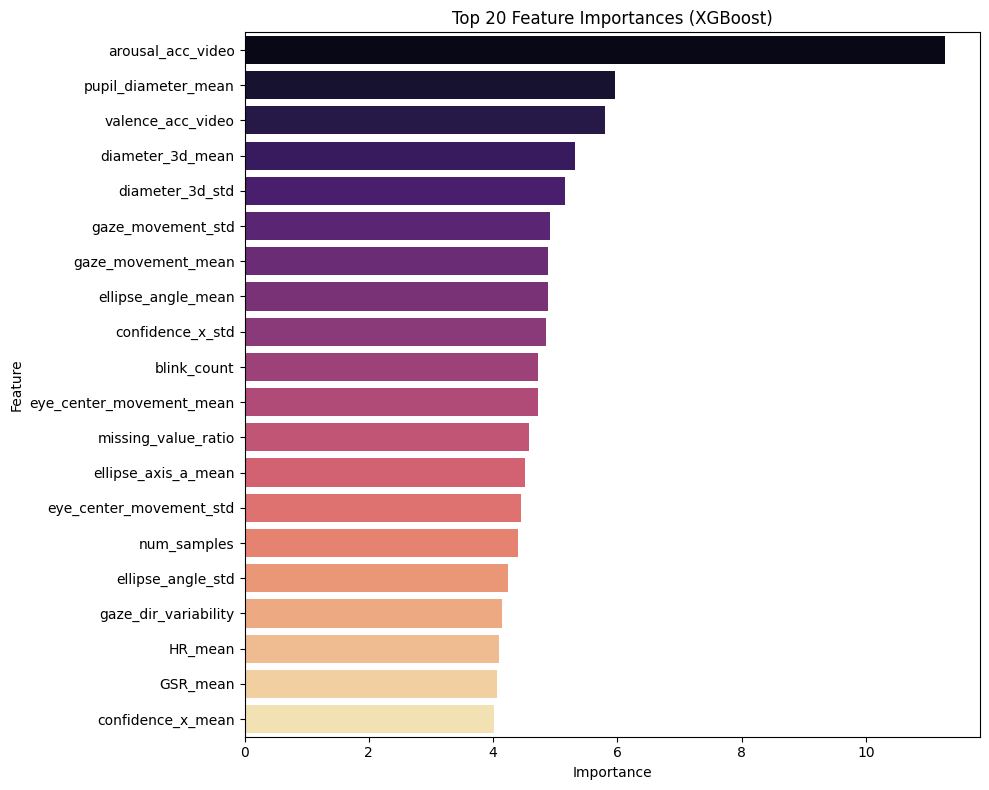

/tmp/ipykernel_1748656/3278568842.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(top_n), x='Importance', y='Feature', palette='magma')


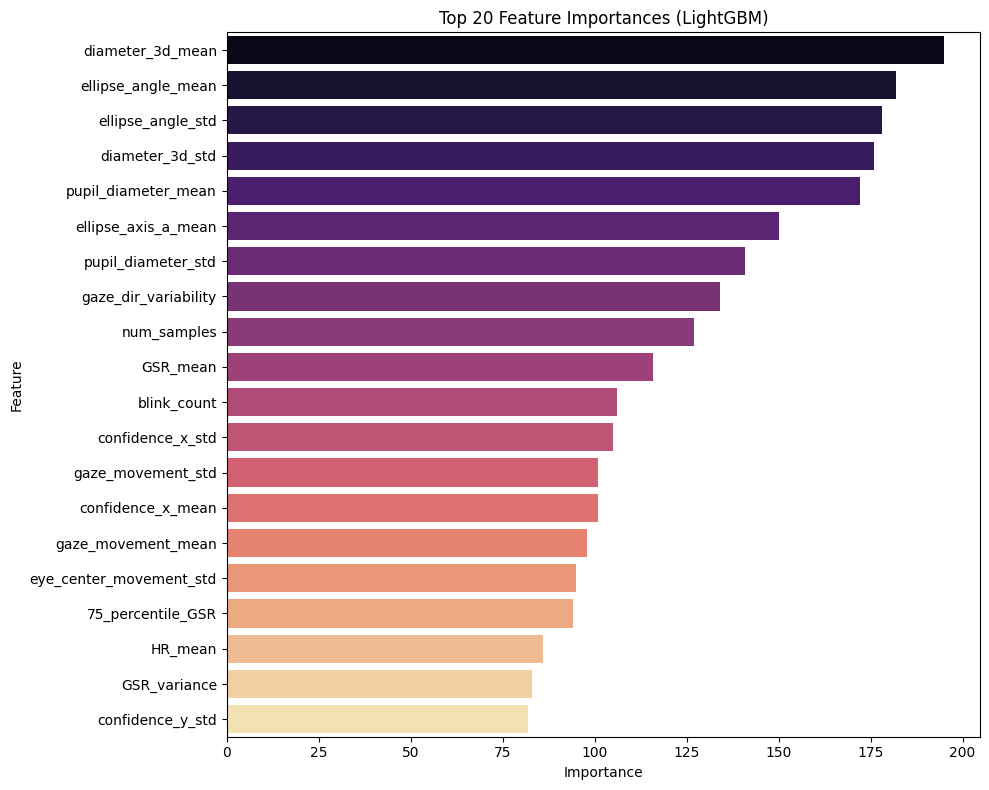

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# --- CLEANING STEPS ---

# 1. Drop constant feature
X = X.drop(columns=['sphere_radius_mean'], errors='ignore')

# 2. Drop duplicate/redundant features
redundant_cols = [
    'GSRmean_diff', 'GSRmean_persen_diff',
    'HRmean_diff', 'HRmean_persent_diff',
    'ellipse_axis_b_mean'  # same as pupil_diameter_mean
]
X = X.drop(columns=[col for col in redundant_cols if col in X.columns])

# 3. Handle outliers (clip to 99th percentile)
clip_cols = ['pupil_diameter_mean', 'pupil_diameter_std']
for col in clip_cols:
    if col in X.columns:
        upper_bound = X[col].quantile(0.99)
        X[col] = X[col].clip(upper=upper_bound)

# 4. Align train/test (assuming you already split into X_train, X_test)
X_train = X.loc[y_train.index]
X_test = X.loc[y_test.index]

# --- FEATURE IMPORTANCE ANALYSIS ---

# Store results for comparison
importance_results = {}

# --- XGBoost ---
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', use_label_encoder=False)
xgb.fit(X_train, y_train)

# Get feature importance from booster
xgb_booster = xgb.get_booster()
raw_importances = xgb_booster.get_score(importance_type='gain')

# Fill in missing features with 0 importance
xgb_full_importance = {feat: raw_importances.get(feat, 0.0) for feat in X.columns}
xgb_df = pd.DataFrame({'Feature': list(xgb_full_importance.keys()), 
                       'Importance': list(xgb_full_importance.values())})
xgb_df = xgb_df.sort_values(by='Importance', ascending=False)
importance_results['XGBoost'] = xgb_df

# --- LightGBM ---
lgbm = LGBMClassifier(n_estimators=100, random_state=42)
lgbm.fit(X_train, y_train)

lgbm_importances = lgbm.feature_importances_
lgbm_df = pd.DataFrame({'Feature': X.columns, 'Importance': lgbm_importances})
lgbm_df = lgbm_df.sort_values(by='Importance', ascending=False)
importance_results['LightGBM'] = lgbm_df

# --- PLOT FUNCTION ---
def plot_feature_importance(df, model_name, top_n=20):
    plt.figure(figsize=(10, 8))
    sns.barplot(data=df.head(top_n), x='Importance', y='Feature', palette='magma')
    plt.title(f'Top {top_n} Feature Importances ({model_name})')
    plt.tight_layout()
    plt.show()

# --- PLOTS ---
plot_feature_importance(xgb_df, 'XGBoost')
plot_feature_importance(lgbm_df, 'LightGBM')


/home/rounak/CODE/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/rounak/CODE/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


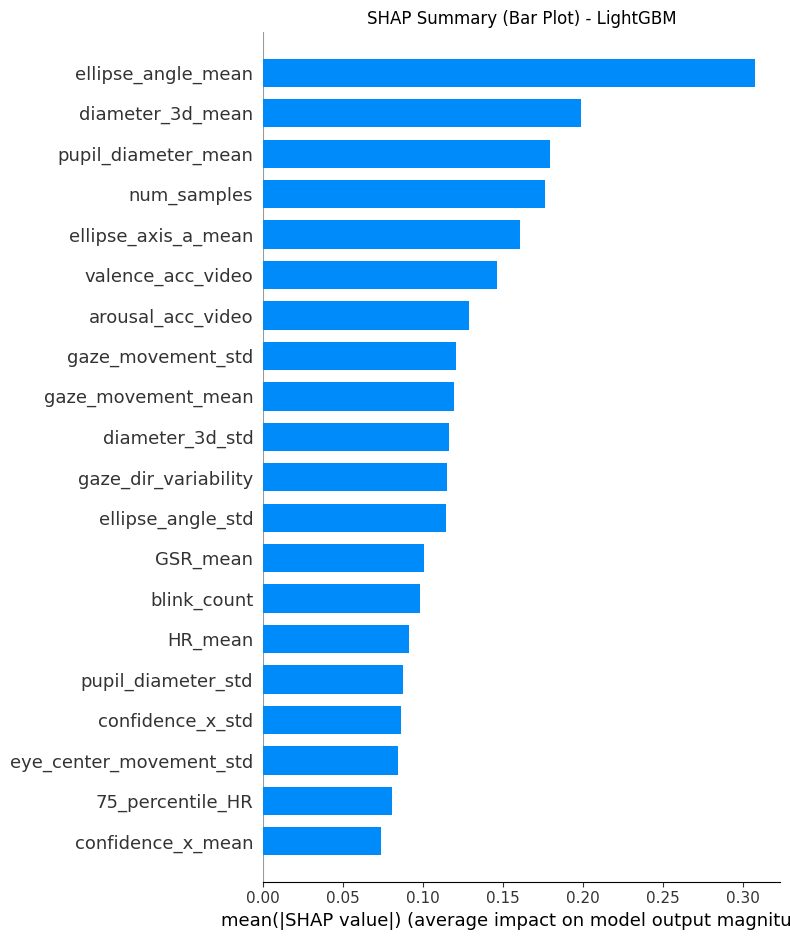

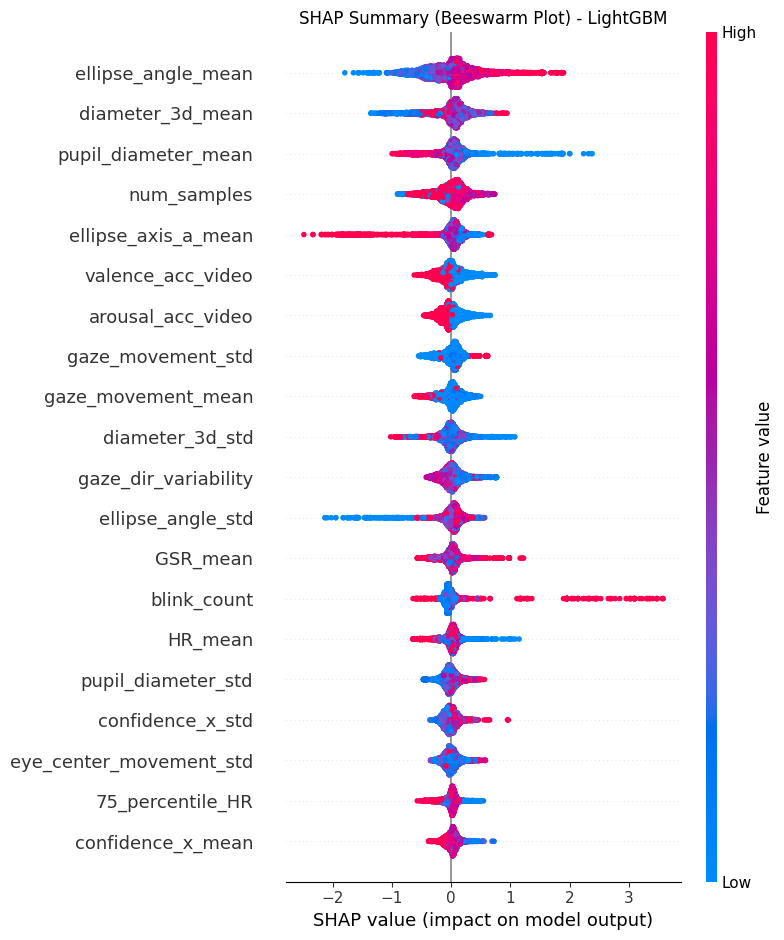

SHAP analysis complete.
SHAP values shape: (7407, 29)
Number of features: 29
Top 5 features by mean absolute SHAP value:
                Feature  Mean |SHAP value|
16   ellipse_angle_mean           0.308021
12     diameter_3d_mean           0.198873
10  pupil_diameter_mean           0.179242
9           num_samples           0.176194
15  ellipse_axis_a_mean           0.160582


In [34]:
import shap

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)


# Use TreeExplainer directly for LightGBM (no PyTorch/torch dependency)
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_train)

# Summary Plot (Bar)
shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
plt.title("SHAP Summary (Bar Plot) - LightGBM")
plt.tight_layout()
plt.show()

# Summary Plot (Beeswarm)
shap.summary_plot(shap_values, X_train, show=False)
plt.title("SHAP Summary (Beeswarm Plot) - LightGBM")
plt.tight_layout()
plt.show()


# --- PRINT SUMMARY INFO ---
print("SHAP analysis complete.")
print(f"SHAP values shape: {np.array(shap_values).shape}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Top 5 features by mean absolute SHAP value:")

# Compute and print top features by mean absolute SHAP value
shap_abs_mean = np.abs(shap_values).mean(axis=0)
top_features = pd.DataFrame({
    'Feature': X_train.columns,
    'Mean |SHAP value|': shap_abs_mean
}).sort_values(by='Mean |SHAP value|', ascending=False)

print(top_features.head(5))



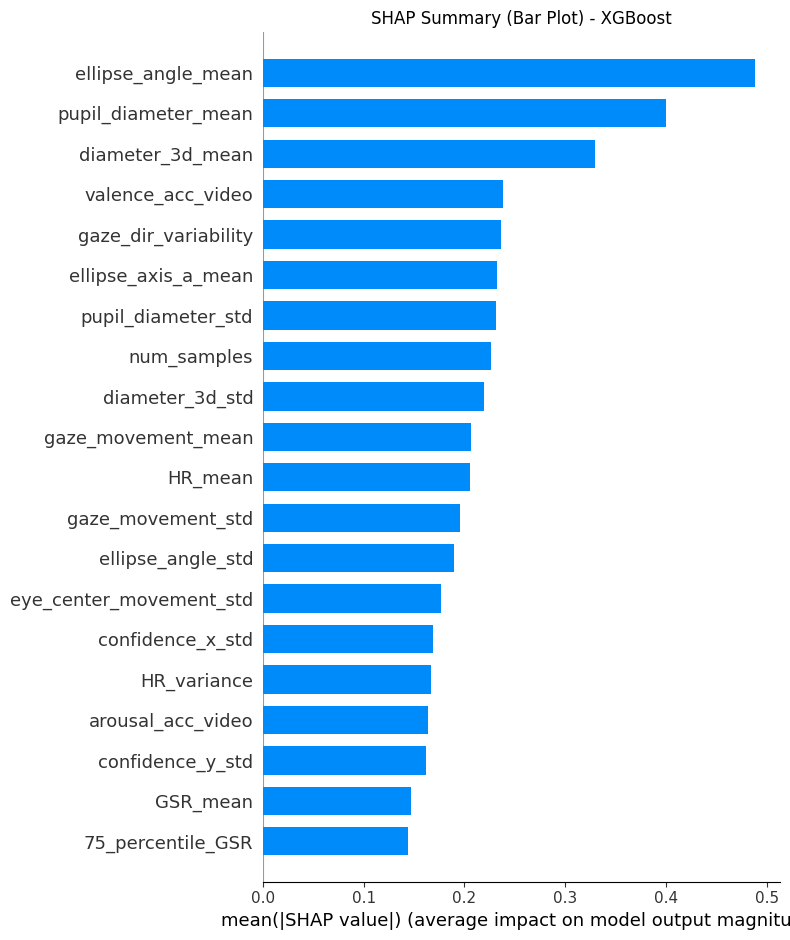

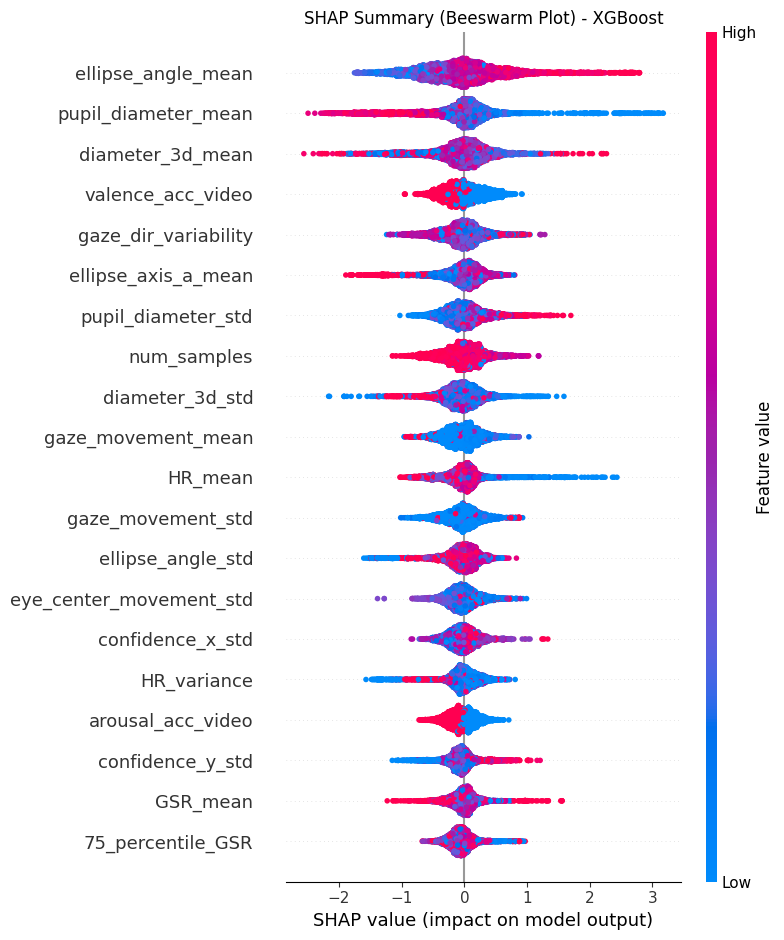

SHAP analysis for XGBoost complete.
SHAP values shape: (7407, 29)
Number of features: 29
Top 5 features by mean absolute SHAP value:
                 Feature  Mean |SHAP value|
16    ellipse_angle_mean           0.488755
10   pupil_diameter_mean           0.399745
12      diameter_3d_mean           0.329254
6      valence_acc_video           0.238254
25  gaze_dir_variability           0.235915


In [36]:
import shap
import matplotlib.pyplot as plt

# SHAP for XGBoost
explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb.shap_values(X_train)

# Summary Plot (Bar)
shap.summary_plot(shap_values_xgb, X_train, plot_type="bar", show=False)
plt.title("SHAP Summary (Bar Plot) - XGBoost")
plt.tight_layout()
plt.show()

# Summary Plot (Beeswarm)
shap.summary_plot(shap_values_xgb, X_train, show=False)
plt.title("SHAP Summary (Beeswarm Plot) - XGBoost")
plt.tight_layout()
plt.show()


# --- PRINT SUMMARY INFO ---
print("SHAP analysis for XGBoost complete.")
print(f"SHAP values shape: {np.array(shap_values_xgb).shape}")
print(f"Number of features: {X_train.shape[1]}")
print("Top 5 features by mean absolute SHAP value:")

# Calculate and display top contributing features
shap_abs_mean_xgb = np.abs(shap_values_xgb).mean(axis=0)
top_features_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Mean |SHAP value|': shap_abs_mean_xgb
}).sort_values(by='Mean |SHAP value|', ascending=False)

print(top_features_xgb.head(5))


In [76]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# SHAP for Random Forest
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_train)  # returns shape (n_samples, n_features, 2)

# Extract SHAP values for positive class (index 1)
shap_values_rf_class1 = shap_values_rf[..., 1]  # Now shape: (n_samples, n_features)

# Summary Plot (Bar)
shap.summary_plot(shap_values_rf_class1, X_train, plot_type="bar", show=False)
plt.title("SHAP Summary (Bar Plot) - Random Forest")
plt.tight_layout()
plt.show()

# Summary Plot (Beeswarm)
shap.summary_plot(shap_values_rf_class1, X_train, show=False)
plt.title("SHAP Summary (Beeswarm Plot) - Random Forest")
plt.tight_layout()
plt.show()

# --- PRINT SUMMARY INFO ---
print("SHAP analysis for Random Forest complete.")
print(f"SHAP values shape: {shap_values_rf_class1.shape}")
print(f"Number of features: {X_train.shape[1]}")
print("Top 5 features by mean absolute SHAP value:")

# Calculate and display top contributing features
shap_abs_mean_rf = np.abs(shap_values_rf_class1).mean(axis=0)
top_features_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Mean |SHAP value|': shap_abs_mean_rf
}).sort_values(by='Mean |SHAP value|', ascending=False)

print(top_features_rf.head(5))


: 

In [25]:
# Step 4: Mutual Information

/tmp/ipykernel_1748656/2089499944.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, y='Feature', x='MI Score', palette='viridis')


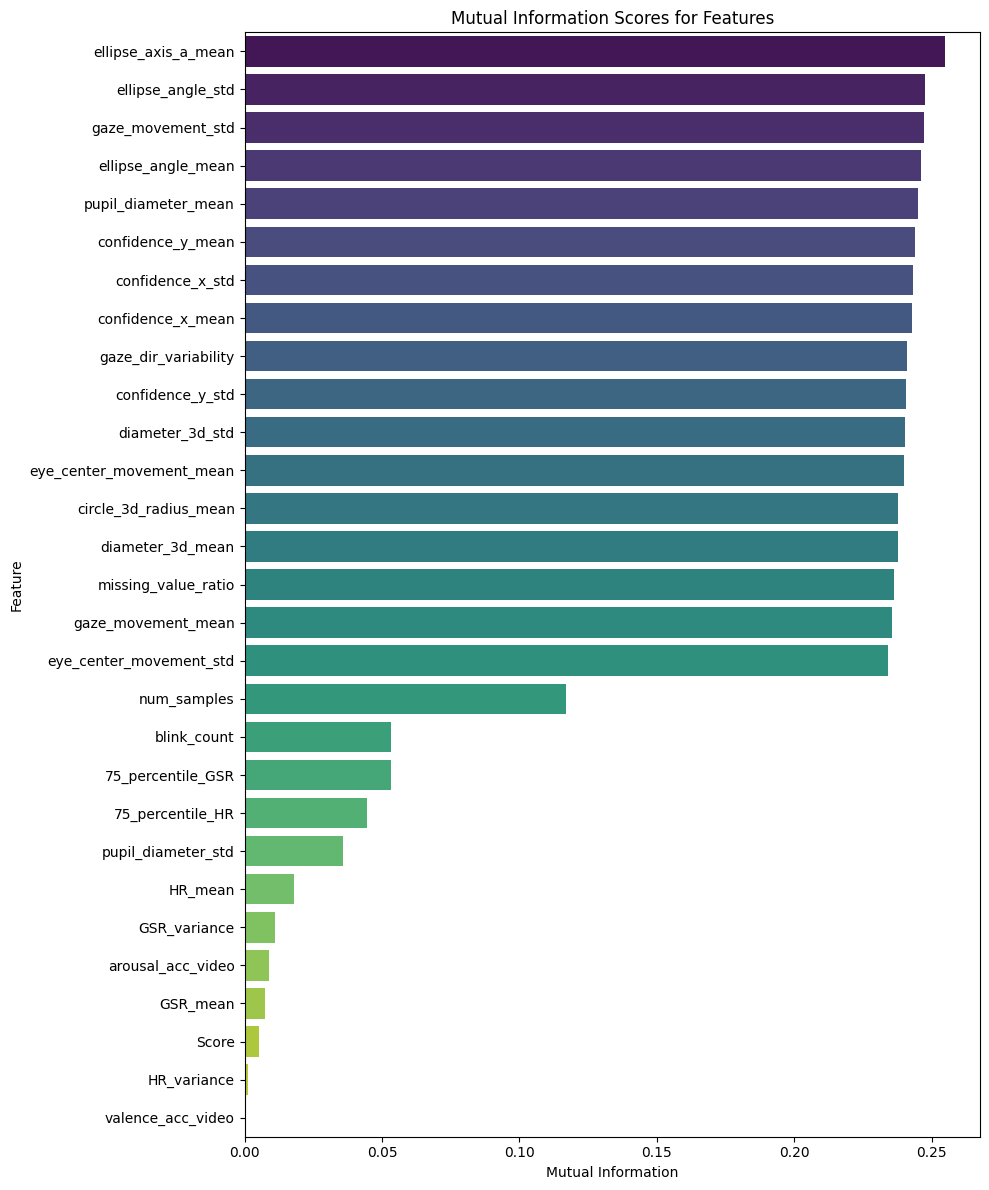

Mutual Information analysis complete.
Number of features evaluated: 29
Top 5 features by Mutual Information score:
                 Feature  MI Score
15   ellipse_axis_a_mean  0.254817
17     ellipse_angle_std  0.247676
24     gaze_movement_std  0.247225
16    ellipse_angle_mean  0.246210
10   pupil_diameter_mean  0.244898
19     confidence_y_mean  0.243900
20      confidence_x_std  0.243336
18     confidence_x_mean  0.242658
25  gaze_dir_variability  0.241085
21      confidence_y_std  0.240712


In [59]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Compute Mutual Information scores
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

# Create a DataFrame for better visualization
mi_df = pd.DataFrame({
    'Feature': X_train.columns,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False)

# Plot the MI scores
plt.figure(figsize=(10, 12))
sns.barplot(data=mi_df, y='Feature', x='MI Score', palette='viridis')
plt.title('Mutual Information Scores for Features')
plt.xlabel('Mutual Information')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# --- PRINT SUMMARY INFO ---
print("Mutual Information analysis complete.")
print(f"Number of features evaluated: {len(mi_scores)}")
print("Top 5 features by Mutual Information score:")

print(mi_df.head(10))



In [36]:
mi_df.head(10)

,Feature,MI Score
15,ellipse_axis_a_mean,0.254817
17,ellipse_angle_std,0.247676
24,gaze_movement_std,0.247225
16,ellipse_angle_mean,0.246210
10,pupil_diameter_mean,0.244898
19,confidence_y_mean,0.243900
20,confidence_x_std,0.243336
18,confidence_x_mean,0.242658
25,gaze_dir_variability,0.241085
21,confidence_y_std,0.240712


In [61]:
from sklearn.feature_selection import SelectKBest, f_classif
import pandas as pd
import numpy as np

# Step 1: Fit SelectKBest with ANOVA F-value
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

# Step 2: Create a DataFrame with scores
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'F_score': selector.scores_,
    'p_value': selector.pvalues_
}).sort_values(by='F_score', ascending=False)

# Step 3: Display top features
print(feature_scores.head(10))


                  Feature     F_score       p_value
22            blink_count  186.724355  3.981444e-42
21       confidence_y_std  132.567497  1.758960e-30
7       arousal_acc_video  110.224363  1.194094e-25
19      confidence_y_mean  101.972589  7.349407e-24
18      confidence_x_mean  100.284863  1.708208e-23
20       confidence_x_std   77.918287  1.256264e-18
14  circle_3d_radius_mean   66.594400  3.742263e-16
12       diameter_3d_mean   66.594400  3.742263e-16
9             num_samples   61.204626  5.670988e-15
16     ellipse_angle_mean   43.641897  4.146327e-11


/tmp/ipykernel_1748656/4195648805.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


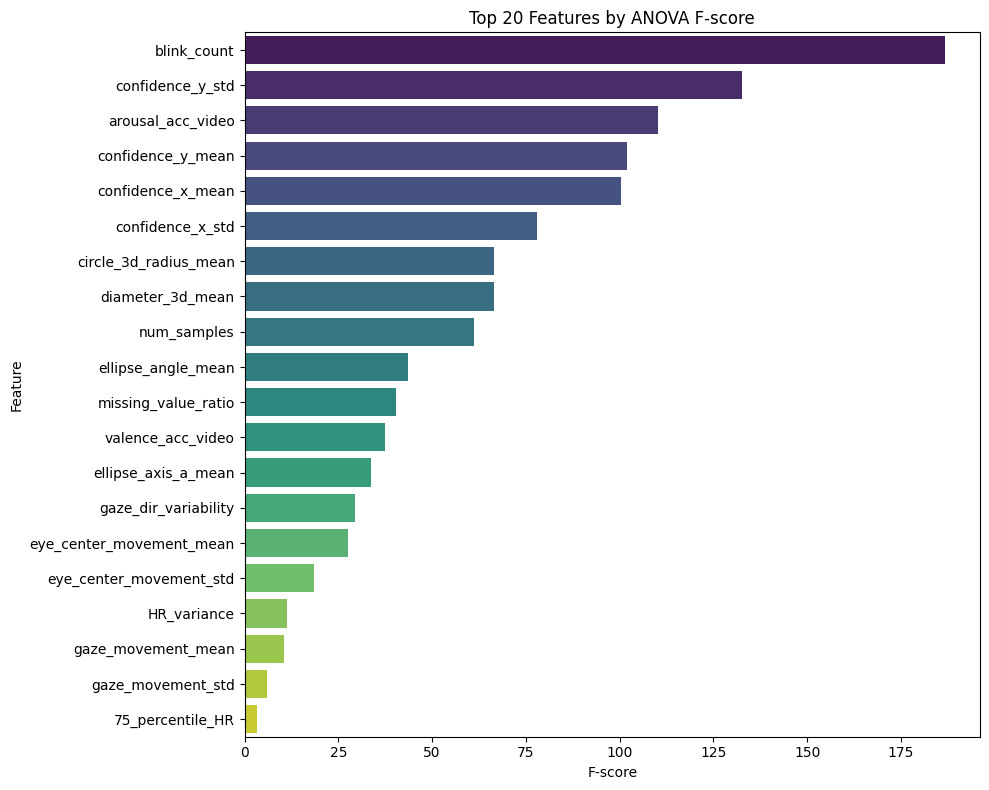

ANOVA F-score feature selection complete.
Number of features evaluated: 29
Top 5 features by F-score:
              Feature     F_score       p_value
22        blink_count  186.724355  3.981444e-42
21   confidence_y_std  132.567497  1.758960e-30
7   arousal_acc_video  110.224363  1.194094e-25
19  confidence_y_mean  101.972589  7.349407e-24
18  confidence_x_mean  100.284863  1.708208e-23


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the top 20 features
plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_scores.sort_values(by="F_score", ascending=False).head(20),
    y="Feature", x="F_score", palette="viridis"
)
plt.title("Top 20 Features by ANOVA F-score")
plt.xlabel("F-score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# --- PRINT SUMMARY INFO ---
print("ANOVA F-score feature selection complete.")
print(f"Number of features evaluated: {feature_scores.shape[0]}")
print("Top 5 features by F-score:")

print(feature_scores.sort_values(by="F_score", ascending=False).head(5))



In [63]:
!pip install statsmodels



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [64]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# Step 1: Drop the target column if still present
X_vif = X_train.copy()

# Step 2: Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vif)

X_scaled_clean = X_scaled[~np.isnan(X_scaled).any(axis=1)]
X_scaled_clean = X_scaled_clean[~np.isinf(X_scaled_clean).any(axis=1)]


# Step 3: Compute VIF DataFrame
vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns  # Make sure X_vif matches X_scaled_clean shape
vif_data['VIF'] = [variance_inflation_factor(X_scaled_clean, i) for i in range(X_scaled_clean.shape[1])]
# Step 4: Sort by VIF score
vif_data_sorted = vif_data.sort_values(by='VIF', ascending=False)

# Display
print(vif_data_sorted)


                     feature          VIF
14     circle_3d_radius_mean          inf
12          diameter_3d_mean          inf
19         confidence_y_mean  1897.444462
18         confidence_x_mean  1827.643106
4          75_percentile_GSR   275.205875
0                   GSR_mean   274.762510
10       pupil_diameter_mean   111.988954
11        pupil_diameter_std   111.779674
5           75_percentile_HR    69.681883
2                    HR_mean    67.306428
23        gaze_movement_mean    16.218561
24         gaze_movement_std    15.748541
21          confidence_y_std    13.255768
20          confidence_x_std    11.821417
1               GSR_variance     8.844919
9                num_samples     8.275111
28       missing_value_ratio     7.563187
26  eye_center_movement_mean     7.484852
27   eye_center_movement_std     7.217003
22               blink_count     4.380475
15       ellipse_axis_a_mean     2.430608
25      gaze_dir_variability     2.262934
17         ellipse_angle_std     1

/home/rounak/CODE/.venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


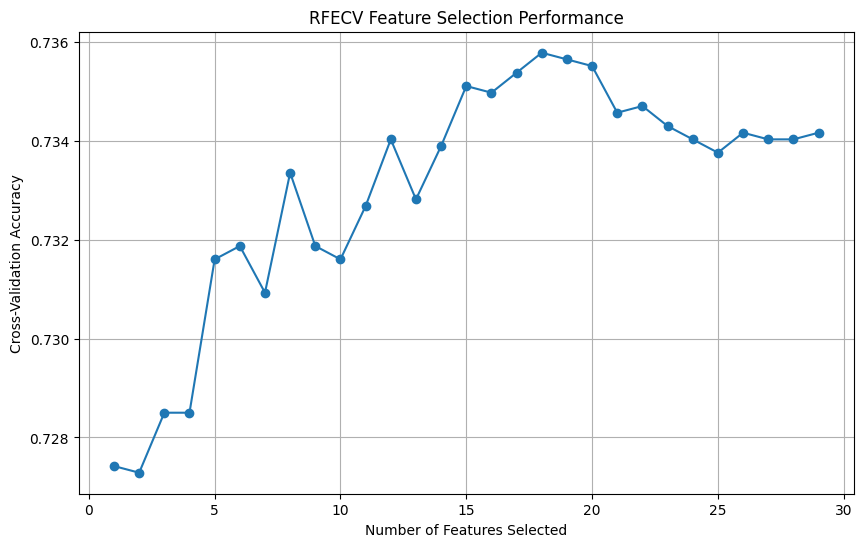

Optimal number of features: 18
Selected features:
['GSR_mean', 'GSR_variance', 'HR_mean', '75_percentile_GSR', '75_percentile_HR', 'valence_acc_video', 'arousal_acc_video', 'num_samples', 'ellipse_axis_a_mean', 'ellipse_angle_mean', 'confidence_x_mean', 'confidence_y_mean', 'confidence_x_std', 'confidence_y_std', 'blink_count', 'gaze_movement_mean', 'gaze_movement_std', 'eye_center_movement_mean']
RFECV feature selection complete.
Total features evaluated: 29
Number of features selected: 18
Top 10 selected features by ranking (if available):
                Feature  Ranking  Selected
0              GSR_mean        1      True
18    confidence_x_mean        1      True
21     confidence_y_std        1      True
16   ellipse_angle_mean        1      True
15  ellipse_axis_a_mean        1      True
22          blink_count        1      True
23   gaze_movement_mean        1      True
19    confidence_y_mean        1      True
9           num_samples        1      True
20     confidence_x_st

In [65]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import pandas as pd

# Copy features (you can optionally drop high-VIF columns here)
X_rfe = X_train.copy()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_rfe_scaled = scaler.fit_transform(X_rfe)


# Define model
# model = LogisticRegression(max_iter=1000)
model = LogisticRegression(solver='saga', max_iter=5000)


# RFECV with 5-fold stratified CV
rfecv = RFECV(
    estimator=model,
    step=1,
    cv=StratifiedKFold(5),
    scoring='accuracy'
)

# Fit RFECV
rfecv.fit(X_rfe_scaled, y_train)

# Get selected features
selected_features = X_rfe.columns[rfecv.support_]

# Get rankings
ranking_df = pd.DataFrame({
    'Feature': X_rfe.columns,
    'Ranking': rfecv.ranking_,
    'Selected': rfecv.support_
}).sort_values(by='Ranking')

# Plot CV accuracy vs number of features
mean_test_scores = rfecv.cv_results_['mean_test_score']

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(mean_test_scores) + 1), mean_test_scores, marker='o')
plt.xlabel("Number of Features Selected")
plt.ylabel("Cross-Validation Accuracy")
plt.title("RFECV Feature Selection Performance")
plt.grid(True)
plt.show()

print(f"Optimal number of features: {rfecv.n_features_}")
print(f"Selected features:\n{selected_features.tolist()}")


# --- PRINT SUMMARY INFO ---
print("RFECV feature selection complete.")
print(f"Total features evaluated: {X_rfe.shape[1]}")
print(f"Number of features selected: {rfecv.n_features_}")
print("Top 10 selected features by ranking (if available):")

print(ranking_df[ranking_df['Selected']].head(10))

# Optional: show full ranking table (sorted)
# print("\nFull feature rankings:")
# print(ranking_df)




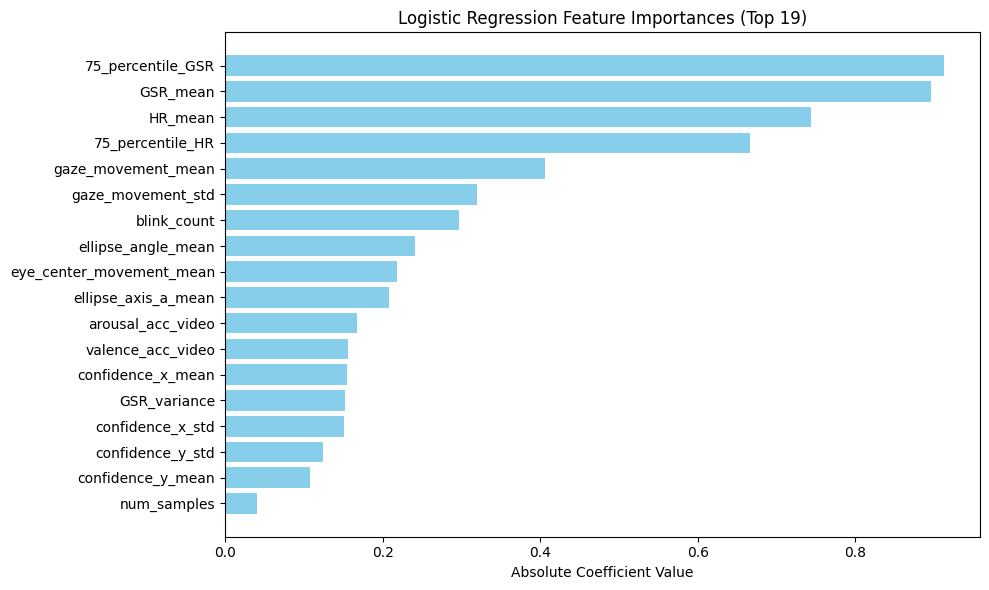

Logistic Regression coefficient analysis complete.
Number of selected features: 18
Top 19 features by absolute coefficient value:
                     Feature  Importance
3          75_percentile_GSR    0.912363
0                   GSR_mean    0.895350
2                    HR_mean    0.744037
4           75_percentile_HR    0.665632
15        gaze_movement_mean    0.406030
16         gaze_movement_std    0.319230
14               blink_count    0.296844
9         ellipse_angle_mean    0.241227
17  eye_center_movement_mean    0.218055
8        ellipse_axis_a_mean    0.208544
6          arousal_acc_video    0.167152
5          valence_acc_video    0.155740
10         confidence_x_mean    0.155455
1               GSR_variance    0.152413
12          confidence_x_std    0.151059
13          confidence_y_std    0.123976
11         confidence_y_mean    0.108204
7                num_samples    0.040488


In [66]:
import numpy as np

# Get coefficients of the selected features
coefs = rfecv.estimator_.coef_.flatten()
selected_feature_names = X_rfe.columns[rfecv.support_]

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': selected_feature_names,
    'Importance': np.abs(coefs)  # Use abs since sign is not as useful here
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel("Absolute Coefficient Value")
plt.title("Logistic Regression Feature Importances (Top 19)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# --- PRINT SUMMARY INFO ---
print("Logistic Regression coefficient analysis complete.")
print(f"Number of selected features: {len(selected_feature_names)}")
print("Top 19 features by absolute coefficient value:")

print(importance_df.head(19))


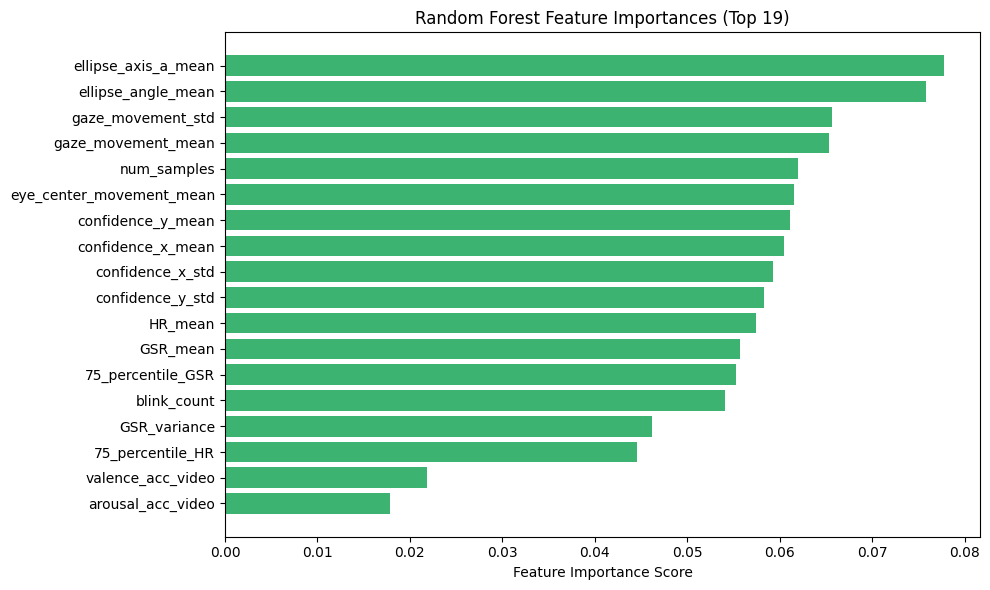

Random Forest feature importance analysis complete.
Number of selected features used: 18
Top 19 features by importance score:
                     Feature  Importance
8        ellipse_axis_a_mean    0.077768
9         ellipse_angle_mean    0.075844
16         gaze_movement_std    0.065631
15        gaze_movement_mean    0.065294
7                num_samples    0.061921
17  eye_center_movement_mean    0.061572
11         confidence_y_mean    0.061088
10         confidence_x_mean    0.060496
12          confidence_x_std    0.059246
13          confidence_y_std    0.058343
2                    HR_mean    0.057377
0                   GSR_mean    0.055722
3          75_percentile_GSR    0.055251
14               blink_count    0.054044
1               GSR_variance    0.046195
4           75_percentile_HR    0.044585
5          valence_acc_video    0.021825
6          arousal_acc_video    0.017797


In [67]:
from sklearn.ensemble import RandomForestClassifier
importances = []

# Step 1: Filter selected features only
X_selected = X_rfe[selected_features]

# Step 2: Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_selected, y_train)

# Step 3: Get feature importances
rf_importance = rf_model.feature_importances_

# Step 4: Create DataFrame for plotting
rf_importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': rf_importance
}).sort_values(by='Importance', ascending=False)

# Step 5: Plot
plt.figure(figsize=(10, 6))
plt.barh(rf_importance_df['Feature'], rf_importance_df['Importance'], color='mediumseagreen')
plt.xlabel("Feature Importance Score")
plt.title("Random Forest Feature Importances (Top 19)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# --- PRINT SUMMARY INFO ---
print("Random Forest feature importance analysis complete.")
print(f"Number of selected features used: {len(selected_features)}")
print("Top 19 features by importance score:")

print(rf_importance_df.head(19))




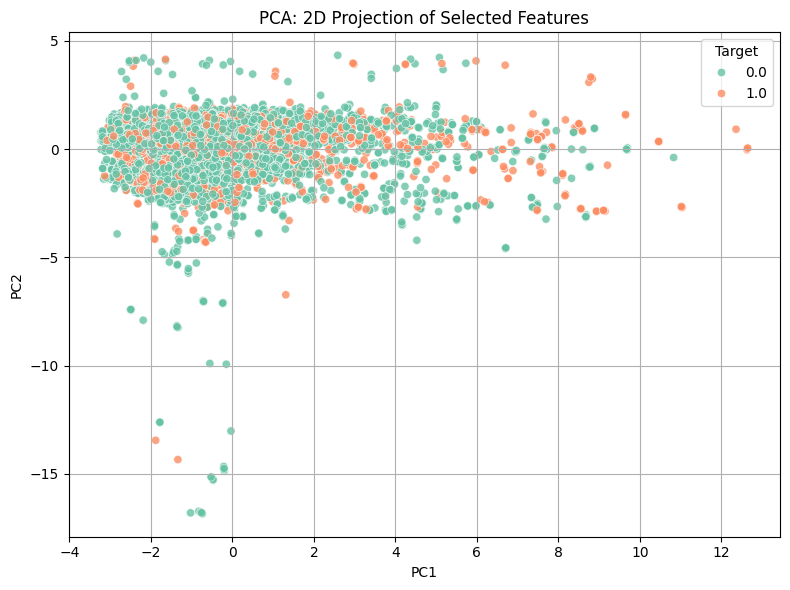

In [74]:
from sklearn.decomposition import PCA
import seaborn as sns

# Use only selected features
X_selected = X_rfe[selected_features]

# Standardize before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for plotting
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Target': y_train.values  # assuming y_train is a Series
})

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Target', palette='Set2', alpha=0.8)
plt.title('PCA: 2D Projection of Selected Features')
plt.grid(True)
plt.tight_layout()
plt.show()


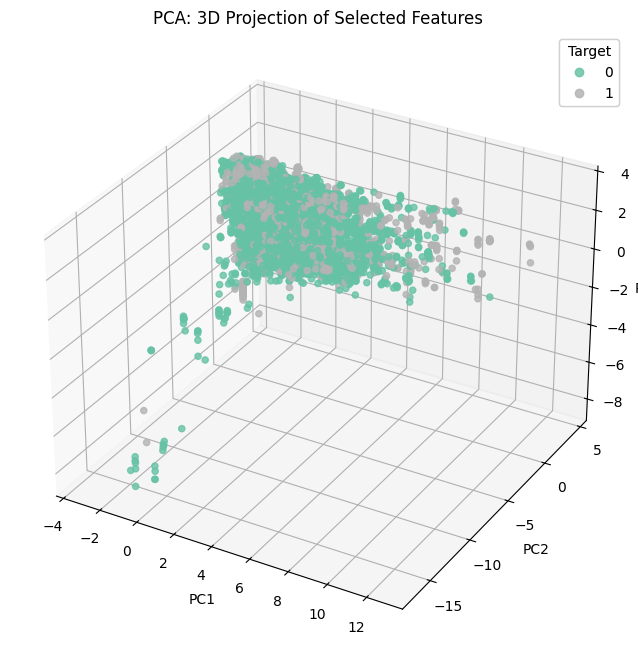

In [69]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

# Use only selected features
X_selected = X_rfe[selected_features]

# Standardize before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

# Apply PCA with 3 components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for plotting
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'PC3': X_pca[:, 2],
    'Target': y_train.values  # assuming y_train is a Series
})

# Plot in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_df['PC1'], 
    pca_df['PC2'], 
    pca_df['PC3'], 
    c=pca_df['Target'], 
    cmap='Set2', 
    alpha=0.8
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('PCA: 3D Projection of Selected Features')

# Add legend
legend = ax.legend(*scatter.legend_elements(), title="Target")
ax.add_artist(legend)

plt.show()


In [75]:
# --- PRINT SUMMARY INFO ---
explained_var = pca.explained_variance_ratio_
print("PCA on selected features complete.")
print(f"Explained variance by PC1: {explained_var[0]:.4f}")
print(f"Explained variance by PC2: {explained_var[1]:.4f}")
print(f"Total variance explained by first 2 PCs: {explained_var.sum():.4f}")


PCA on selected features complete.
Explained variance by PC1: 0.2752
Explained variance by PC2: 0.1328
Total variance explained by first 2 PCs: 0.4080


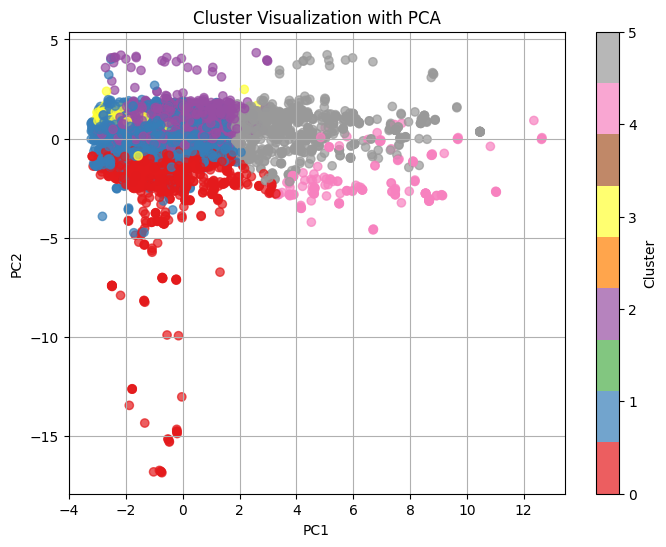

In [71]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_rfe[selected_features])

# Perform clustering (KMeans example)
kmeans = KMeans(n_clusters=6, random_state=42)  # adjust n_clusters as needed
cluster_labels = kmeans.fit_predict(X_scaled)

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create DataFrame for plotting
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': cluster_labels
})

# Plot clusters
plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Cluster'], cmap='Set1', alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Cluster Visualization with PCA')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()


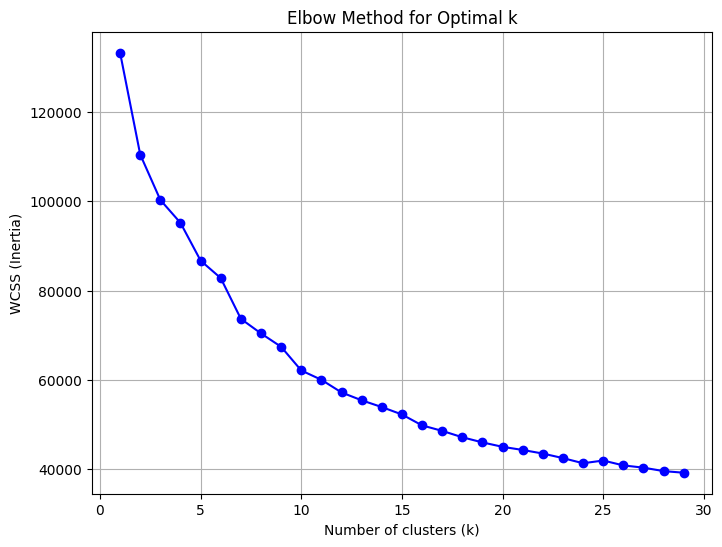

In [72]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
K = range(1, 30)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(K, wcss, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()


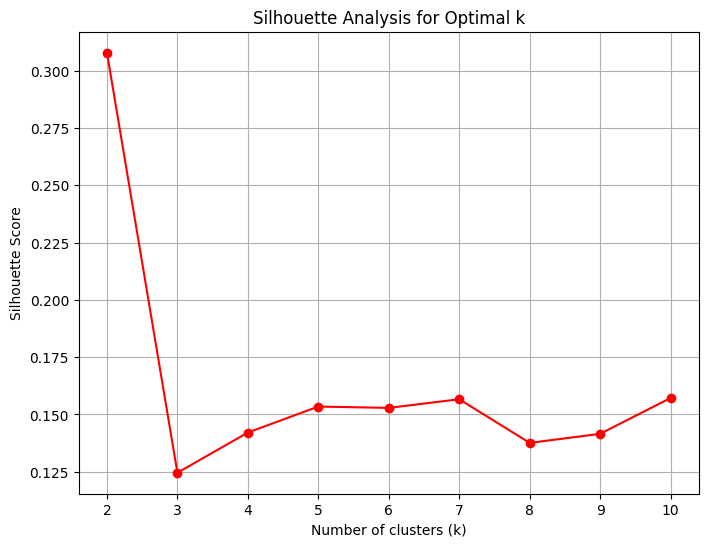

In [73]:
from sklearn.metrics import silhouette_score

sil_scores = []
K = range(2, 11)  # silhouette needs at least 2 clusters
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

plt.figure(figsize=(8, 6))
plt.plot(K, sil_scores, 'ro-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis for Optimal k')
plt.grid(True)
plt.show()
